# 2. Clusterização de Eventos (GMM)

Esta seção apresenta a aplicação do Modelo de Mistura Gaussiana (GMM) para identificar padrões latentes de comportamento na rede. O objetivo é agrupar as transições detectadas em categorias semânticas com base na correlação multivariada das métricas.

## 2.1 Seleção do Número de Componentes ($K$)

Para determinar o número ideal de clusters, avaliamos o desempenho do modelo variando o parâmetro $K$. A escolha baseia-se no equilíbrio entre o ajuste aos dados e a complexidade do modelo, utilizando critérios de informação estatística:

* **AIC/BIC:** Indicadores que penalizam modelos com excesso de parâmetros. Valores menores sugerem um melhor compromisso entre ajuste e simplicidade do modelo.
* **Log-Likelihood (LL):** Mede quão bem os parâmetros do modelo explicam os dados. Aumentos no LL indicam que o modelo descreve melhor a amostra.
* **Delta_BIC/Delta_LL:** Quantificam o ganho marginal ao adicionar um novo cluster. Delta_BIC negativo indica ganho de qualidade e Delta_LL positivo indica melhor ajuste aos dados.

> **Nota técnica:** A escolha do $K$ final busca evitar a fragmentação excessiva dos dados, priorizando um número de clusters que possua significado físico (ex: separação clara entre Congestionamento e Mudança de Rota).

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re

# --- Parâmetros do Estudo ---
SCENARIO = "NDT"
METHOD = "vwcd_fp1"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# Caminho dos relatórios baseado no cenário atual
path = os.path.join("clusters", SCENARIO)

if not os.path.exists(path):
    print(f"Erro: Pasta {path} não encontrada.")
else:
    data = []
    
    # Regex para capturar K do nome do arquivo e os valores dentro do TXT
    # Utiliza as variáveis globais METHOD (vwcd), REF_METRIC (full) e THRESHOLD
    file_pattern = rf"clusters_K(\d+)_features_{METHOD}_{REF_METRIC}_{THRESHOLD}\.txt"    

    for file in os.listdir(path):
        match = re.match(file_pattern, file)
        if match:
            k_val = int(match.group(1))
            full_path = os.path.join(path, file)
            
            with open(full_path, 'r') as f:
                content = f.read()
                
                # Extração via Regex dos valores numéricos
                aic = re.search(r"AIC.*: ([\d\.-]+)", content)
                bic = re.search(r"BIC.*: ([\d\.-]+)", content)
                ll  = re.search(r"Log-Likelihood: ([\d\.-]+)", content)
                events = re.search(r"Total de Eventos: (\d+)", content)
                
                if aic and bic and ll:
                    data.append({
                        'K': k_val,
                        'Log-Likelihood': float(ll.group(1)),
                        'AIC': float(aic.group(1)),
                        'BIC': float(bic.group(1))
                    })

    if not data:
        print("Nenhum relatório encontrado para os parâmetros fornecidos.")
    else:
        # Criar DataFrame e ordenar por K
        df_comp = pd.DataFrame(data).sort_values('K').reset_index(drop=True)
        
        # Calcular a diferença (Delta) entre o K atual e o anterior
        df_comp['Delta_LL']  = df_comp['Log-Likelihood'].diff()
        df_comp['Delta_AIC'] = df_comp['AIC'].diff()
        df_comp['Delta_BIC'] = df_comp['BIC'].diff()

        # Colocar 0 se o Delta for NaN (primeira linha)
        df_comp['Delta_LL'] = df_comp['Delta_LL'].fillna(0)
        df_comp['Delta_AIC'] = df_comp['Delta_AIC'].fillna(0)
        df_comp['Delta_BIC'] = df_comp['Delta_BIC'].fillna(0)

        print(f"\nCOMPARAÇÃO DE MODELOS - CENÁRIO: {SCENARIO}")
        print(f"Métrica: {REF_METRIC} | Threshold: {THRESHOLD}")
        print("=" * 85)
        print(df_comp.to_string(index=False))
        print("=" * 85)


COMPARAÇÃO DE MODELOS - CENÁRIO: NDT
Métrica: rtt_down | Threshold: 0.95
 K  Log-Likelihood    AIC    BIC  Delta_LL  Delta_AIC  Delta_BIC
 2         -170.13 422.25 518.35      0.00       0.00       0.00
 3         -107.78 339.55 484.87     62.35     -82.70     -33.48
 4          -47.36 260.72 455.25     60.42     -78.83     -29.62
 5           -5.83 219.66 463.42     41.53     -41.06       8.17
 6           35.31 179.39 472.37     41.14     -40.27       8.95
 7           88.71 114.57 456.77     53.40     -64.82     -15.60
 8          172.74 -11.48 379.93     84.03    -126.05     -76.84
 9          191.53  -7.05 433.58     18.79       4.43      53.65
10          248.89 -79.78 410.08     57.36     -72.73     -23.50


## 2.2 Análise dos Parâmetros e Assinaturas dos Clusters



In [11]:
# --- Parâmetros do Estudo ---
K_CLUSTERS = 8

# printar os valores de Log-Likelihood AIC BIC puxando de df_comp
if 'Log-Likelihood' in df_comp.columns and 'AIC' in df_comp.columns and 'BIC' in df_comp.columns:
    ll_value = df_comp.loc[df_comp['K'] == K_CLUSTERS, 'Log-Likelihood'].values[0]
    aic_value = df_comp.loc[df_comp['K'] == K_CLUSTERS, 'AIC'].values[0]
    bic_value = df_comp.loc[df_comp['K'] == K_CLUSTERS, 'BIC'].values[0]
    print(f"\nResultados para K={K_CLUSTERS}:")
    print(f"Log-Likelihood: {ll_value}")
    print(f"AIC: {aic_value}")
    print(f"BIC: {bic_value}")
else:
    print("Colunas de Log-Likelihood, AIC ou BIC não encontradas em df_comp.")


Resultados para K=8:
Log-Likelihood: 172.74
AIC: -11.48
BIC: 379.93


In [12]:
# Caminho dos relatórios baseado no cenário atual
file_name = f"clusters_K{K_CLUSTERS:02d}_features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv"
full_path = os.path.join("clusters", SCENARIO, file_name)

# ler o csv para um DataFrame
if not os.path.exists(full_path):
    print(f"Erro: Arquivo {full_path} não encontrado.")
else:
    df_clusters = pd.read_csv(full_path)

# Agrupando por cluster para contar as ocorrências (changepoints) e calcular as médias
result = df_clusters.groupby('cluster').agg({
    'timestamp': 'count',
    'd_rtt_up': 'mean',
    'd_rtt_down': 'mean',
    'd_tp_up': 'mean',
    'd_tp_down': 'mean',
    'd_pl': 'mean'
})

# Renomeando a coluna de contagem para clareza
result = result.rename(columns={'timestamp': 'num_cps'})

print(result)

         num_cps  d_rtt_up  d_rtt_down   d_tp_up  d_tp_down      d_pl
cluster                                                              
0              6 -0.601415   -0.670780  0.163824   0.516308 -0.014283
1              7  4.672757    4.412687 -0.513345  -0.652437  0.026481
2              2 -0.803343   -0.806162  1.150937   2.646922  0.025235
3             27 -0.467084   -0.478373  0.065875   0.177191  0.015774
4              8  2.008147    2.388809 -0.217088  -0.435007  0.005497
5             22  1.149532    1.171577 -0.060281  -0.145527 -0.015498
6              2  6.000244    6.020646 -0.449170  -0.712623 -0.058812
7              3 -0.824314   -0.823319  1.138561   1.908885 -0.016983


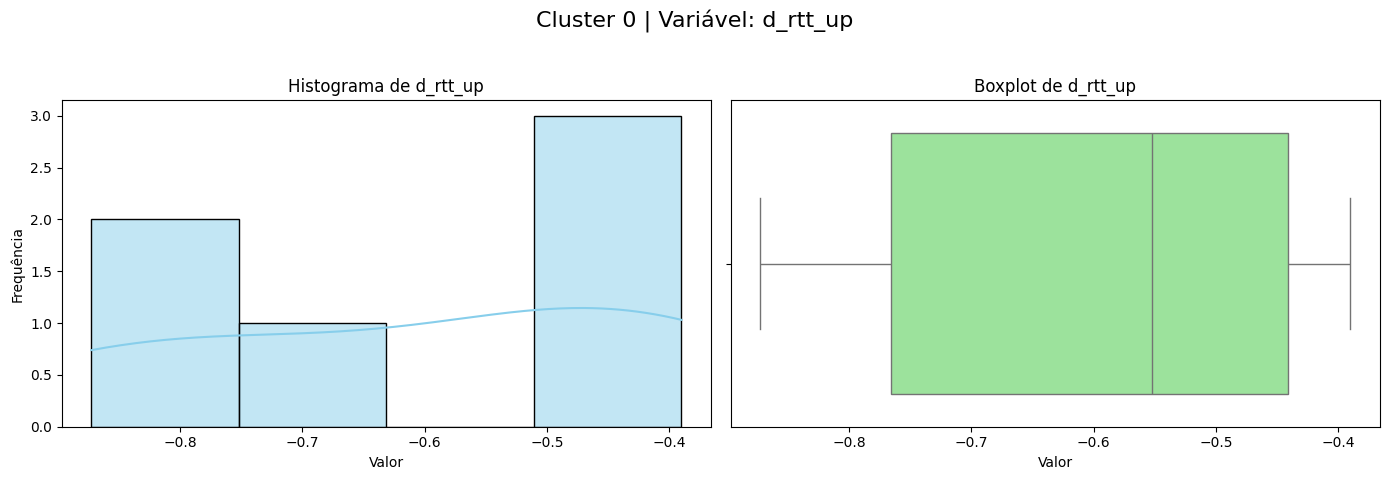

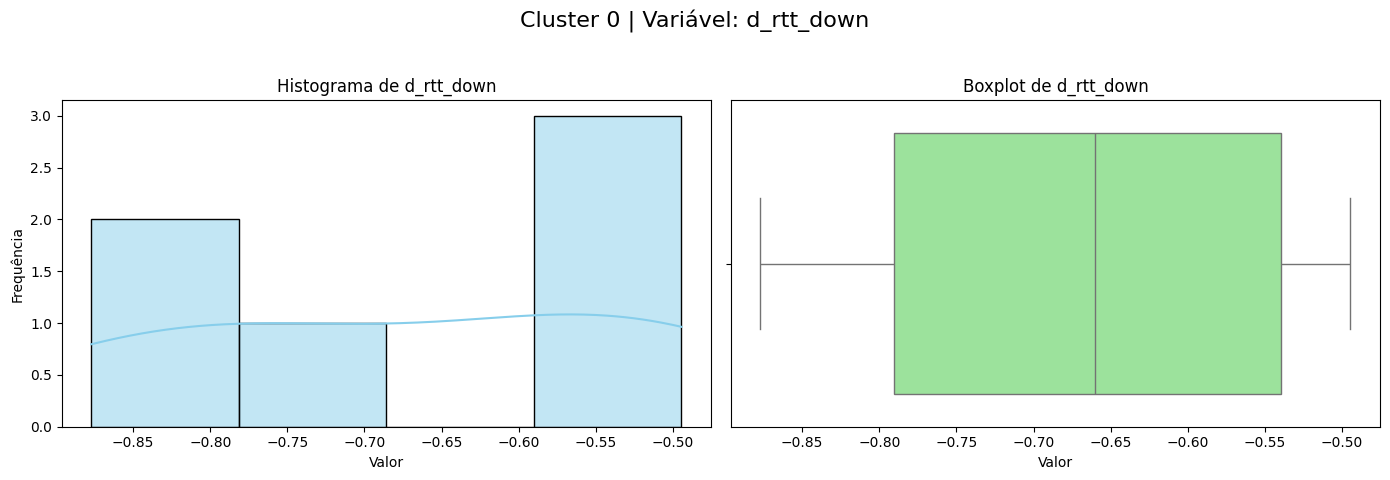

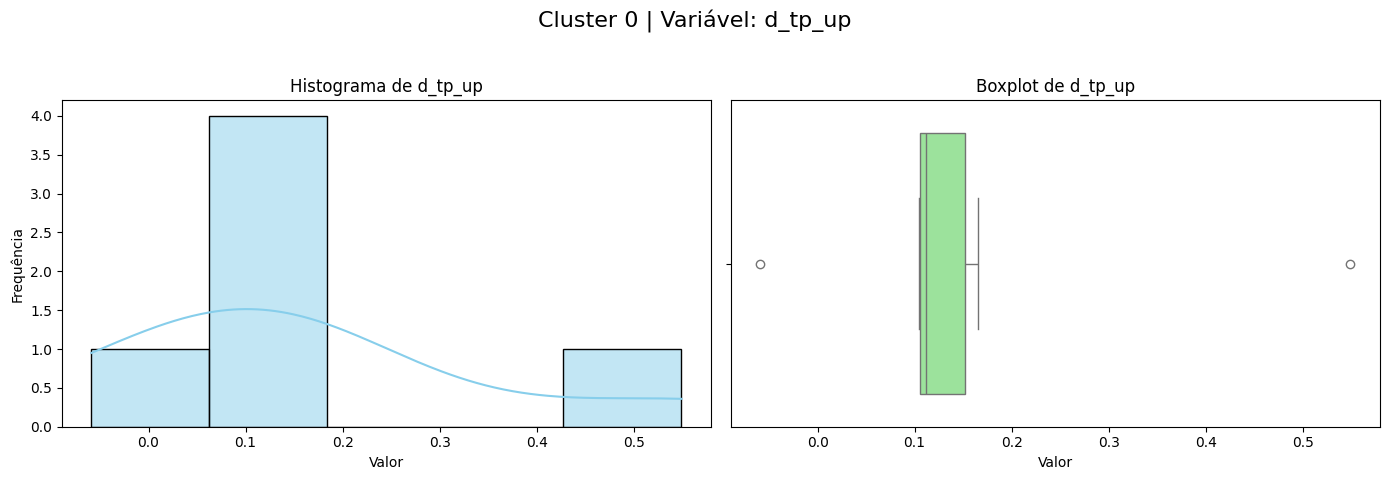

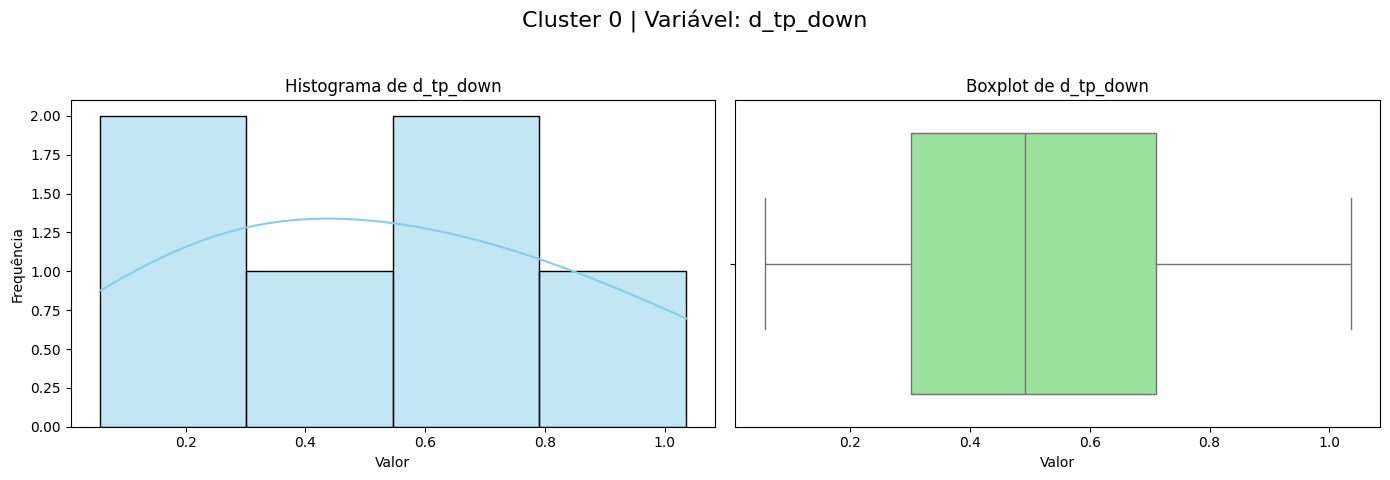

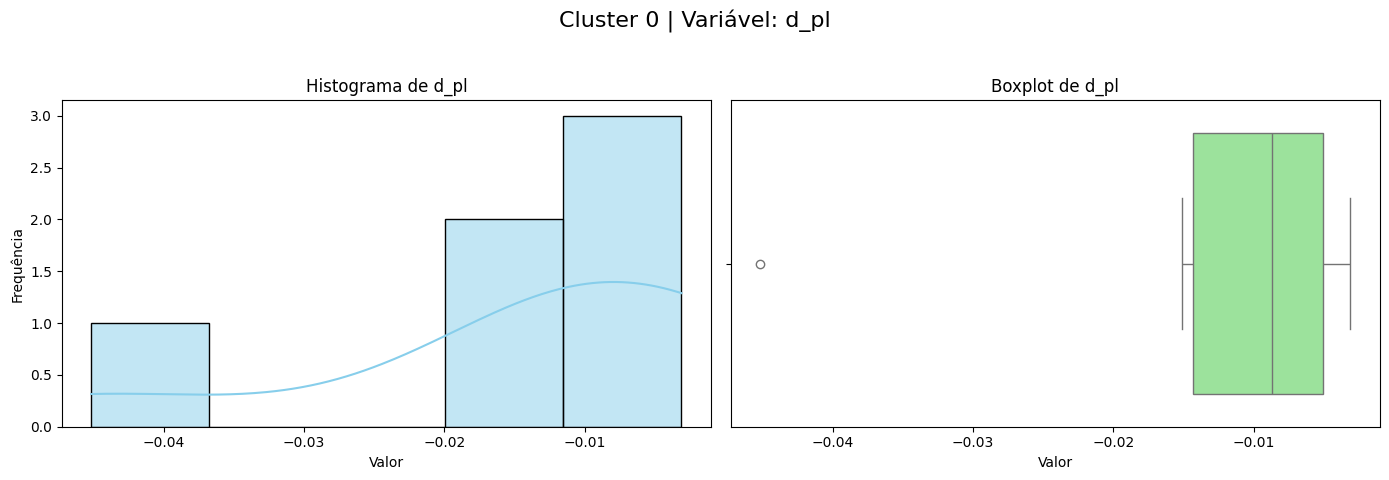

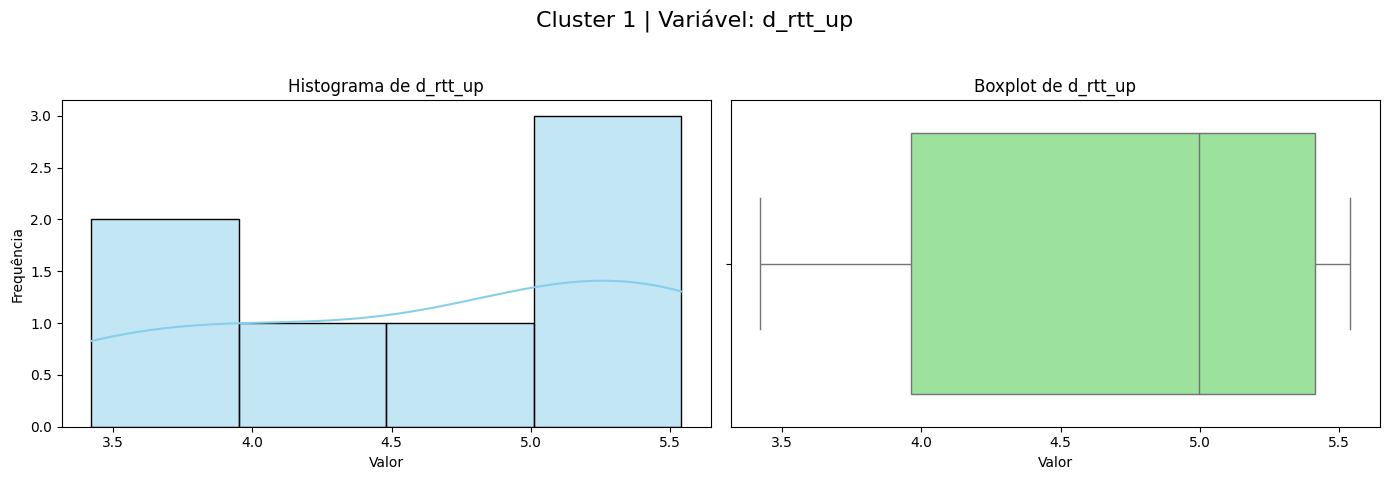

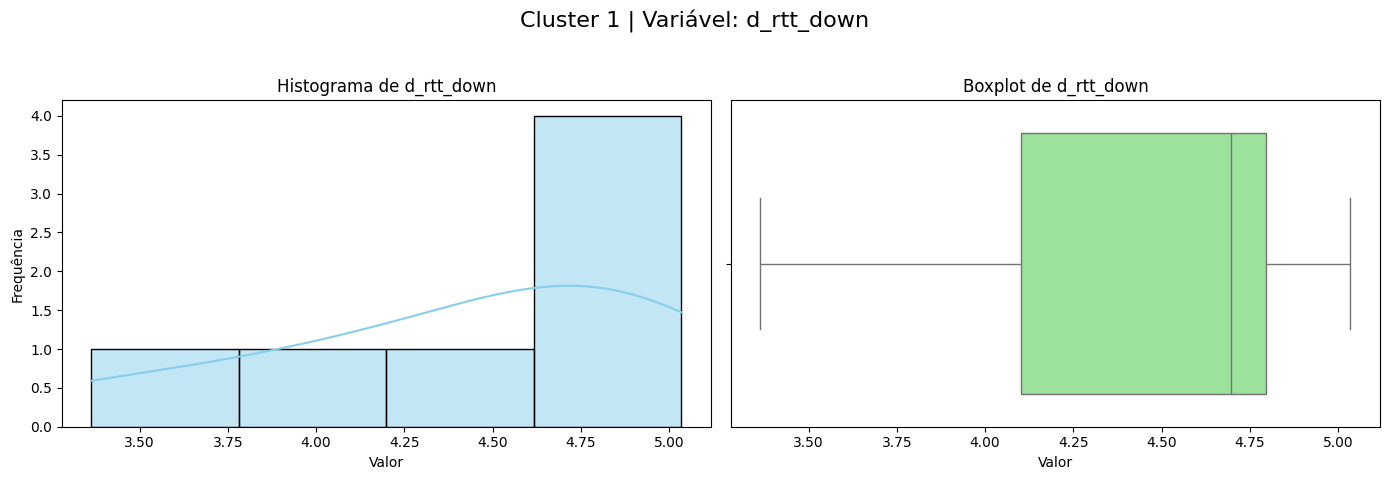

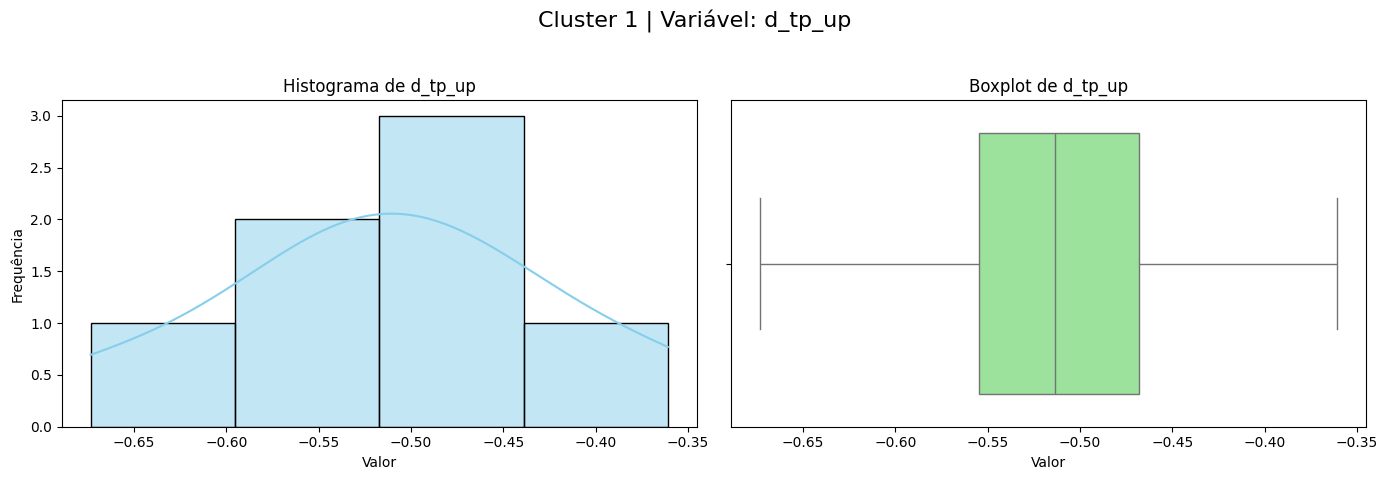

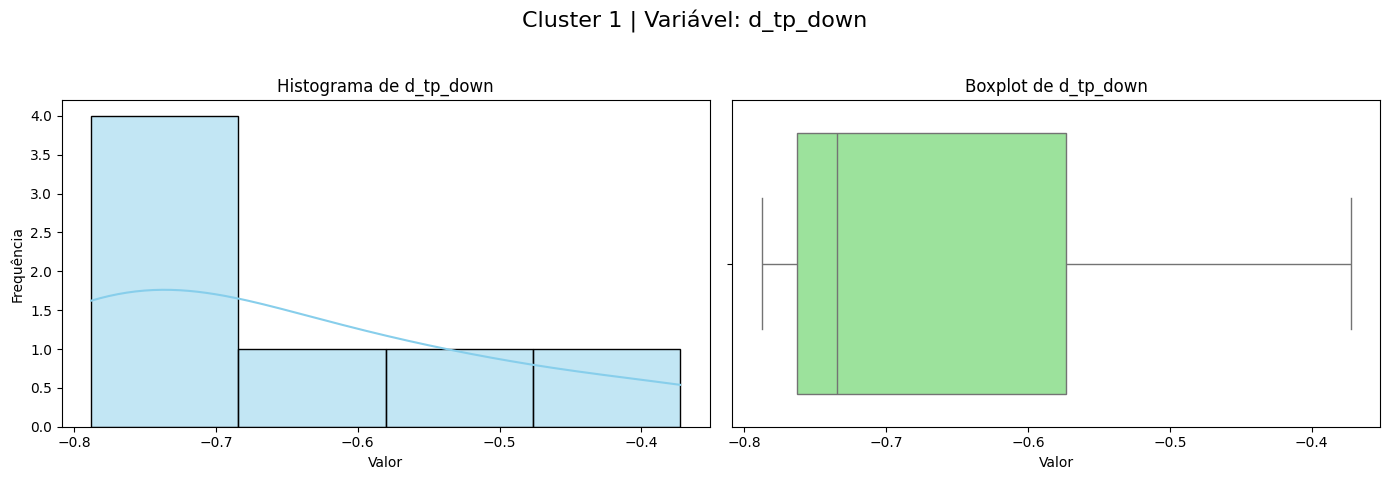

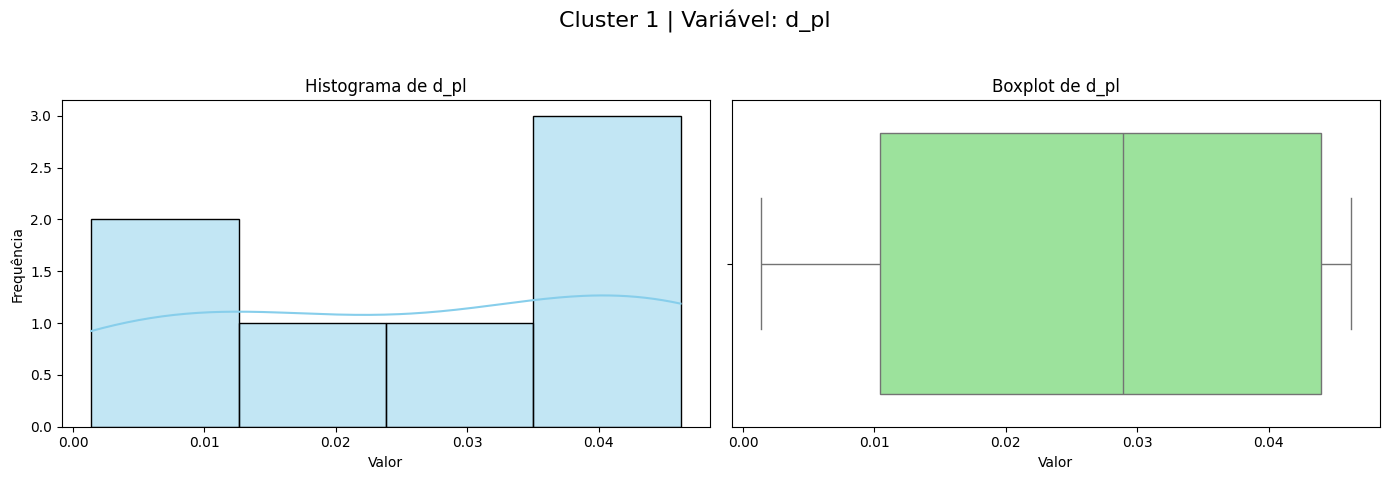

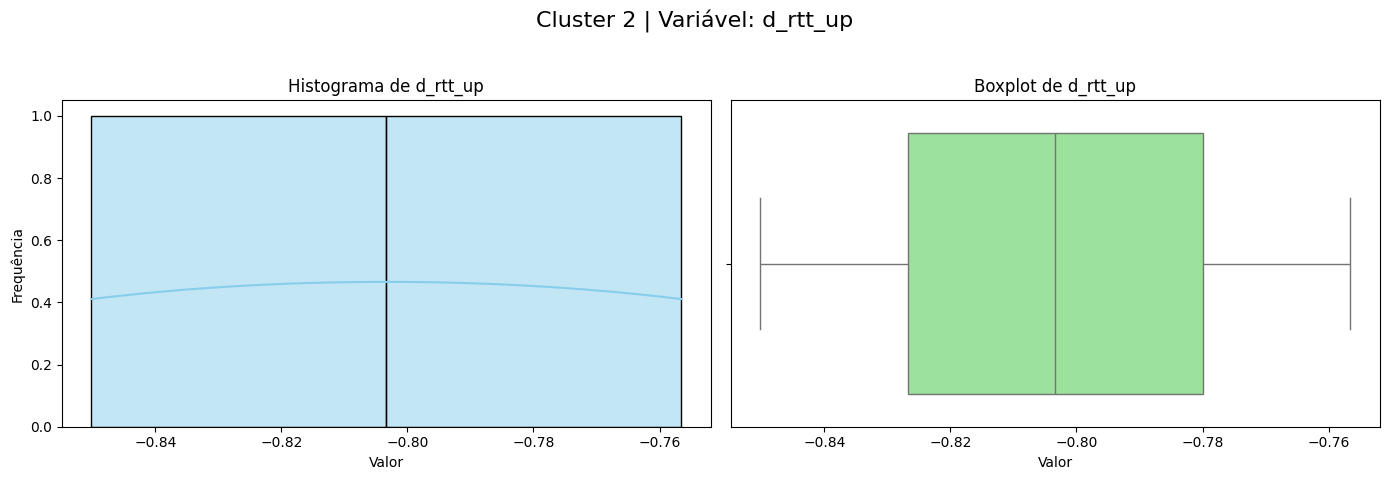

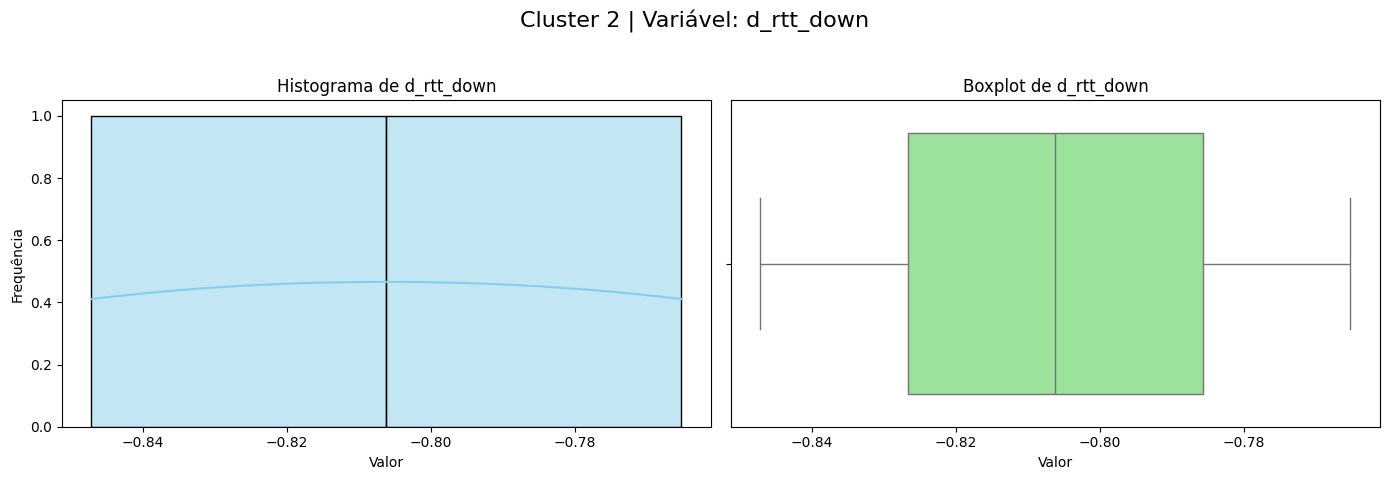

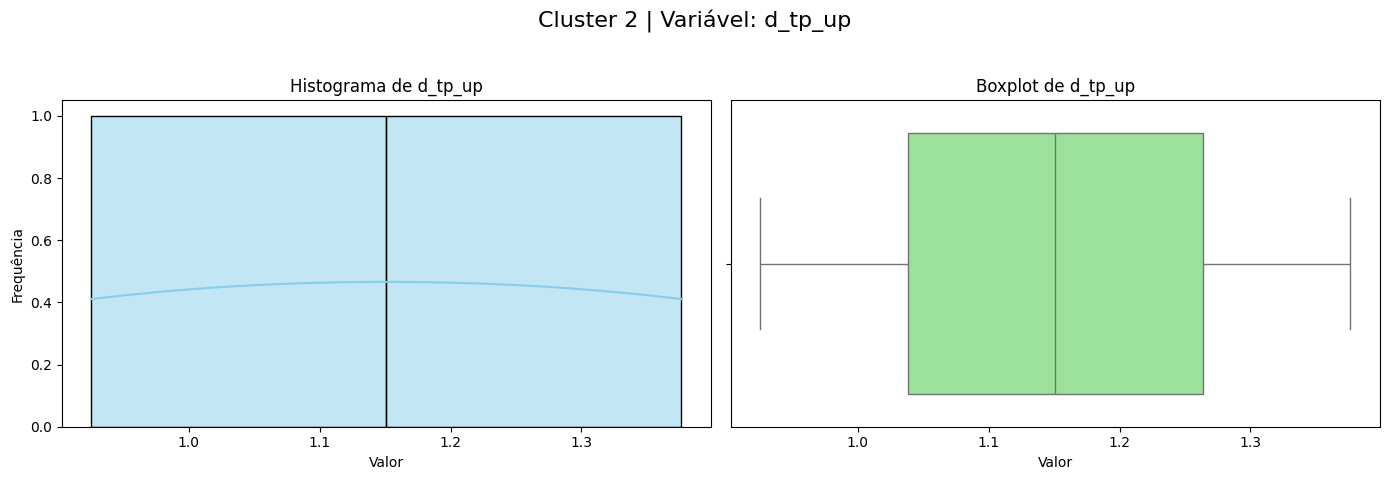

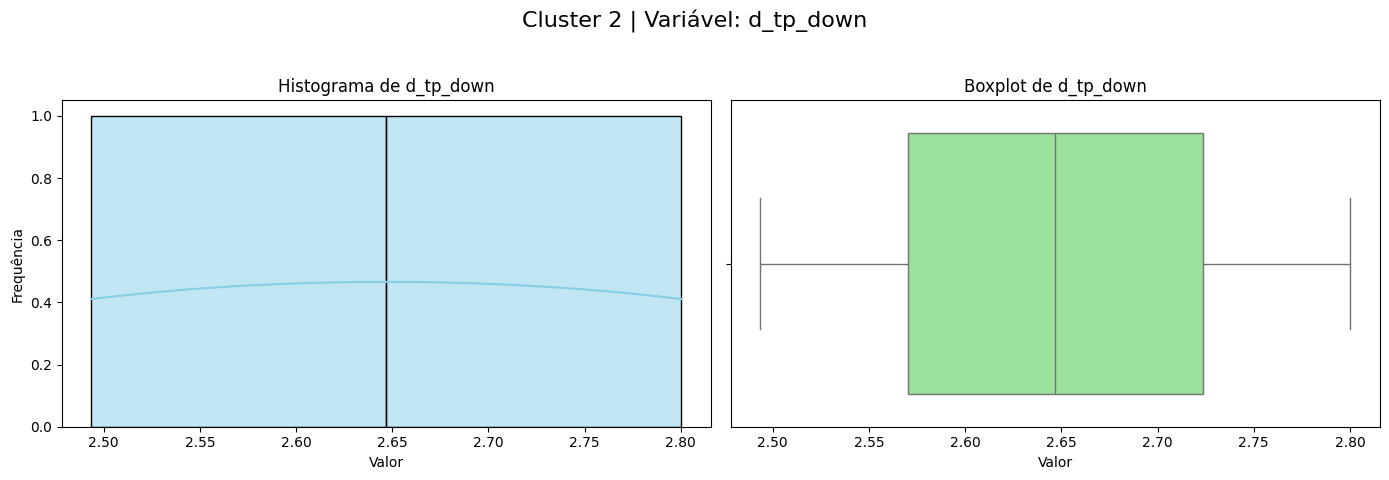

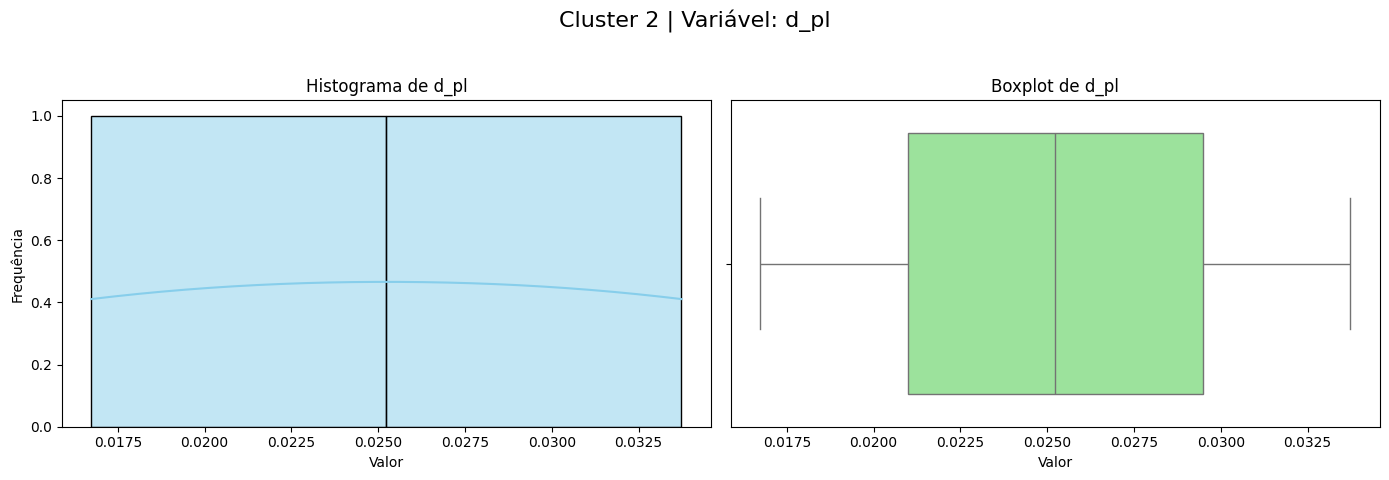

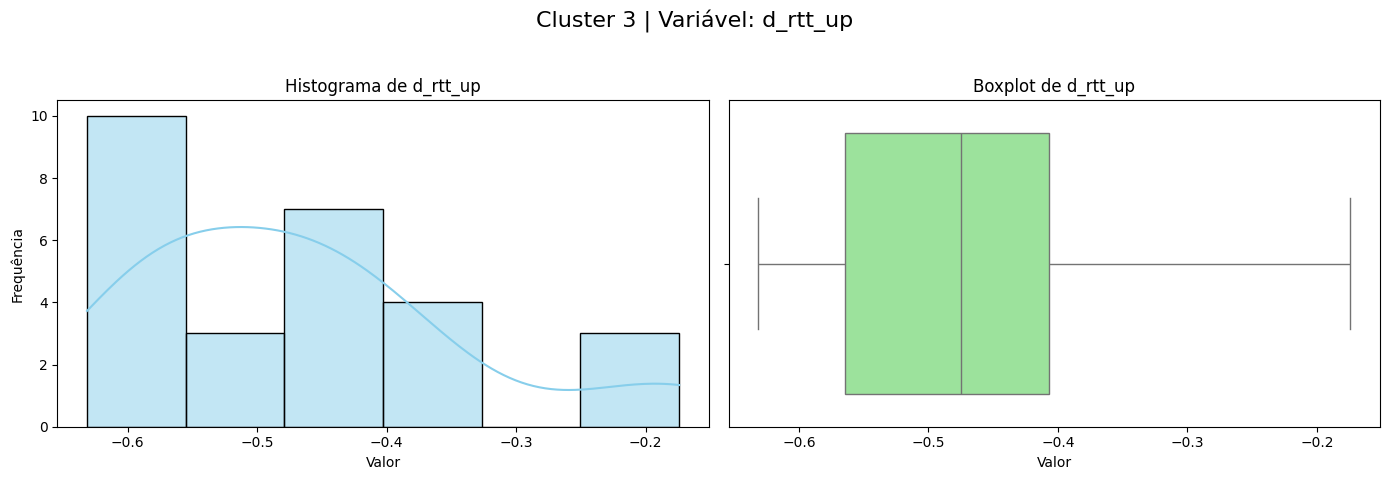

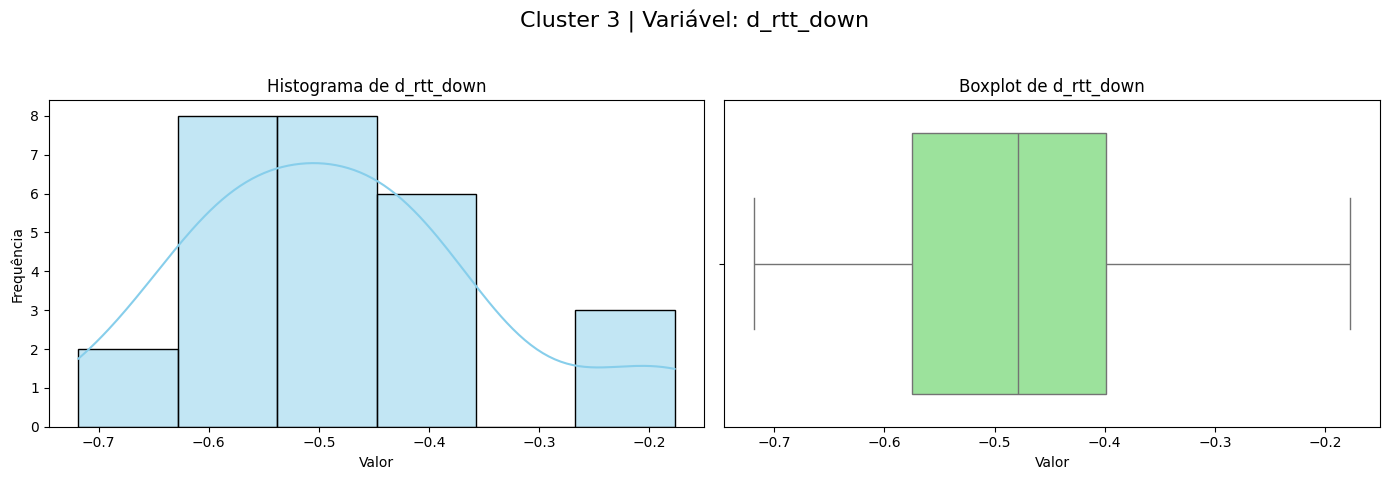

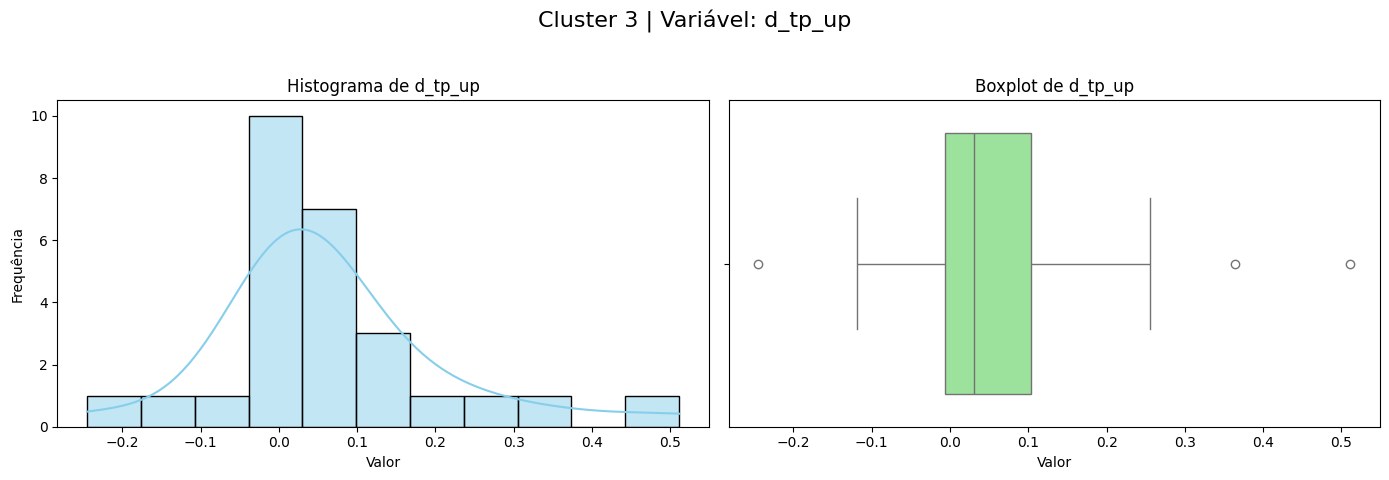

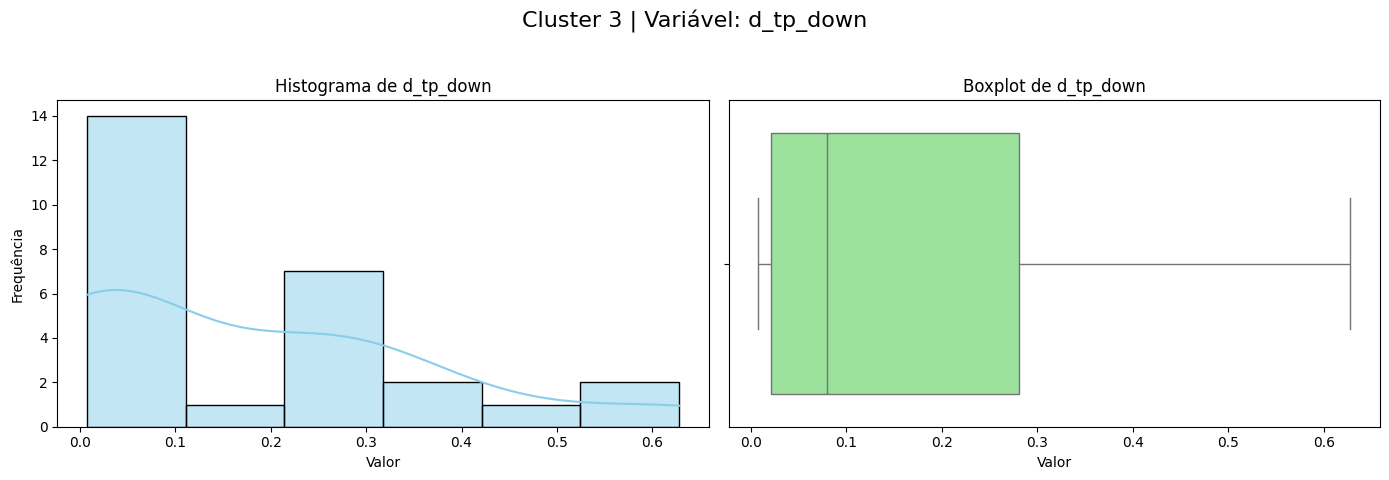

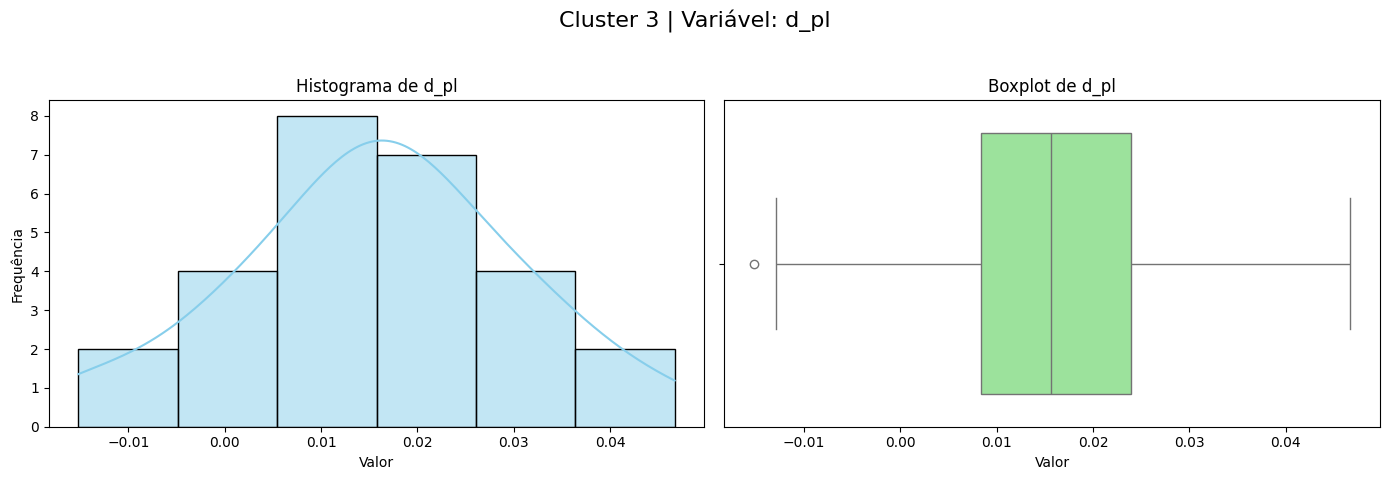

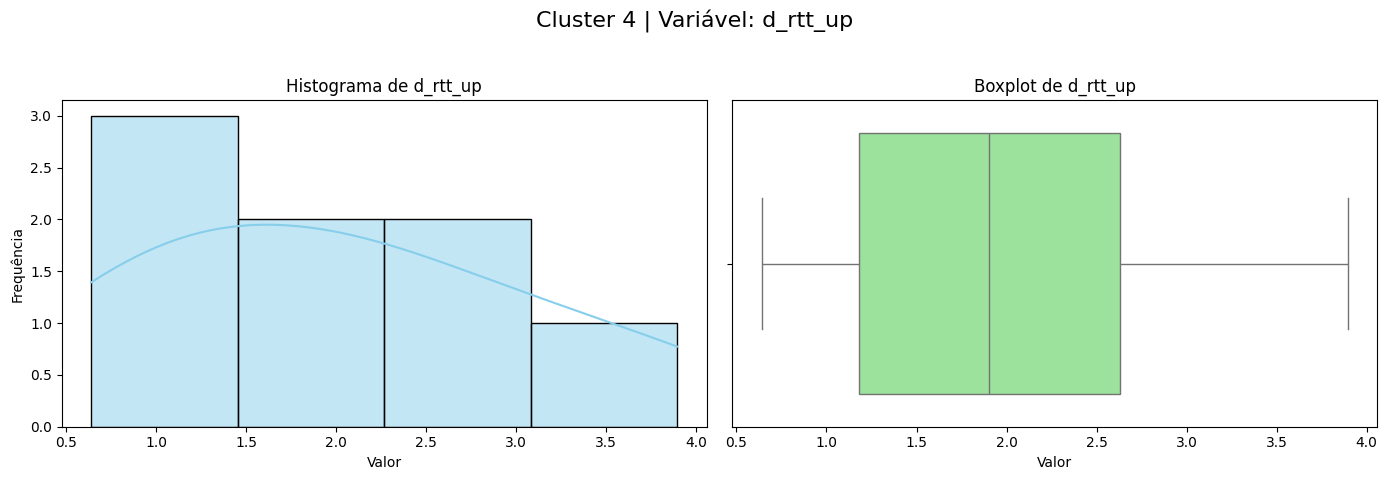

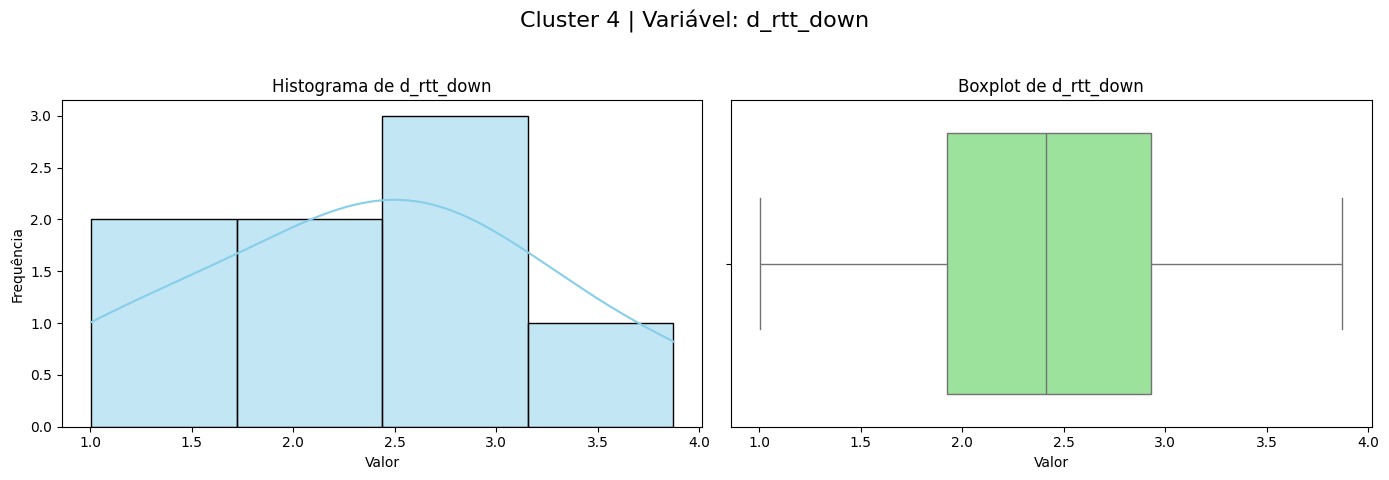

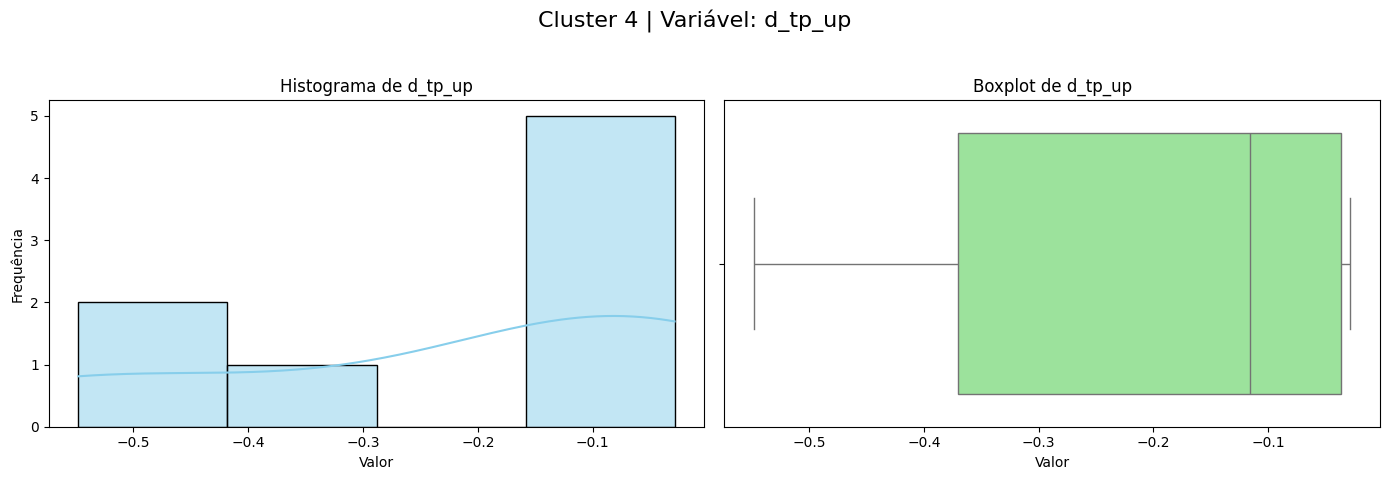

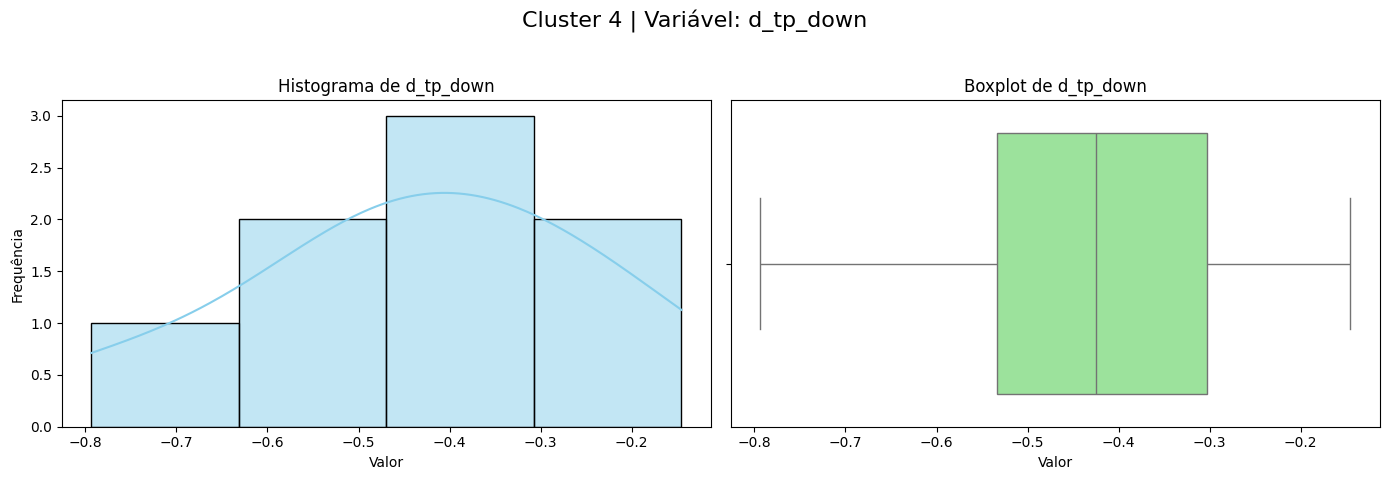

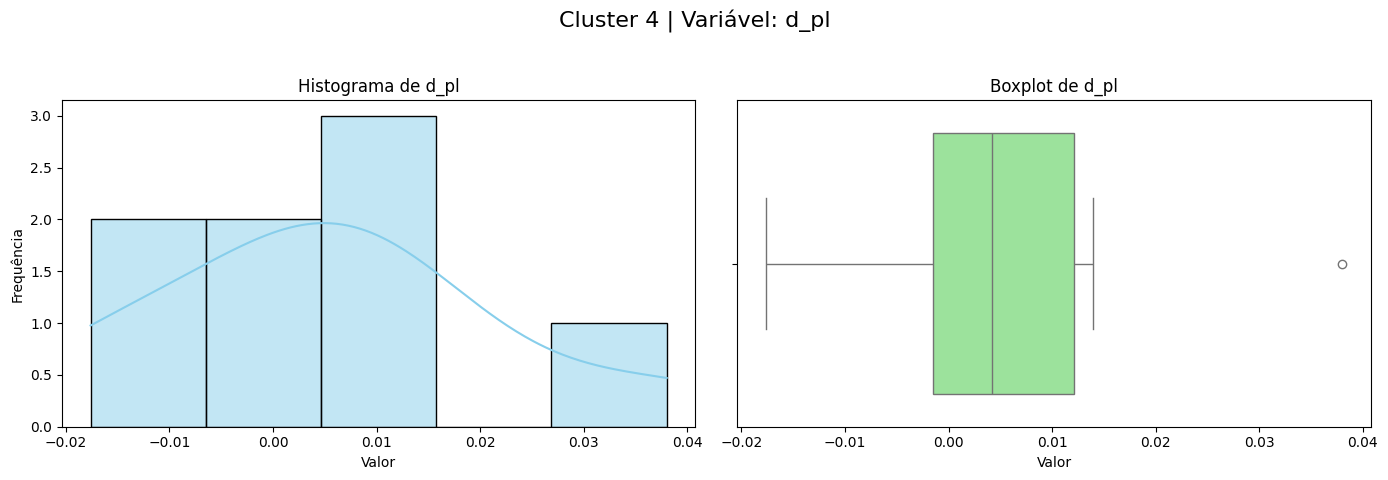

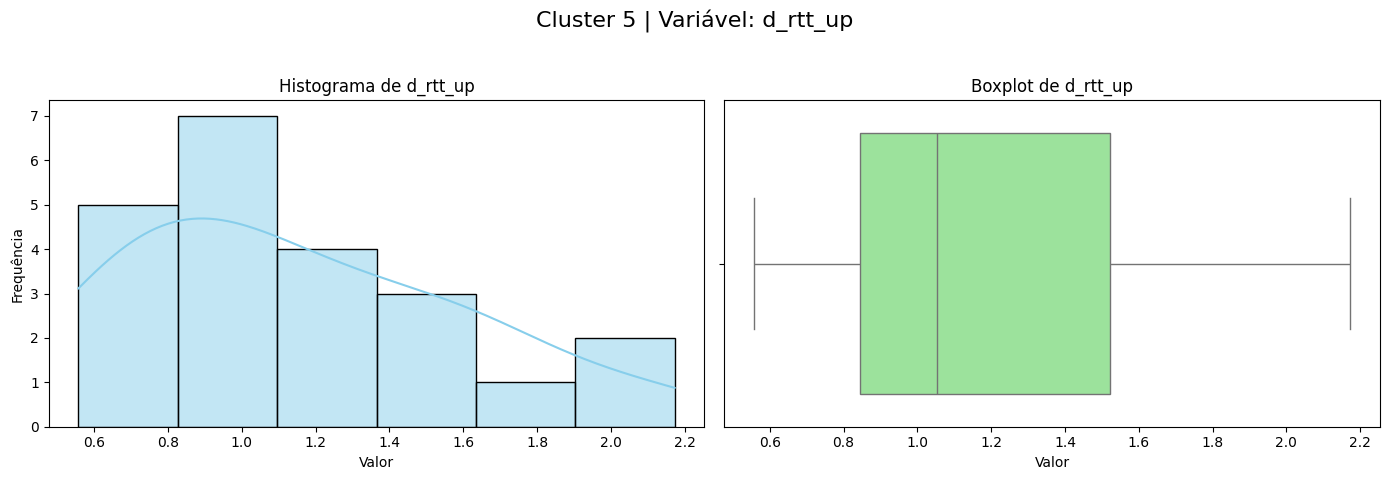

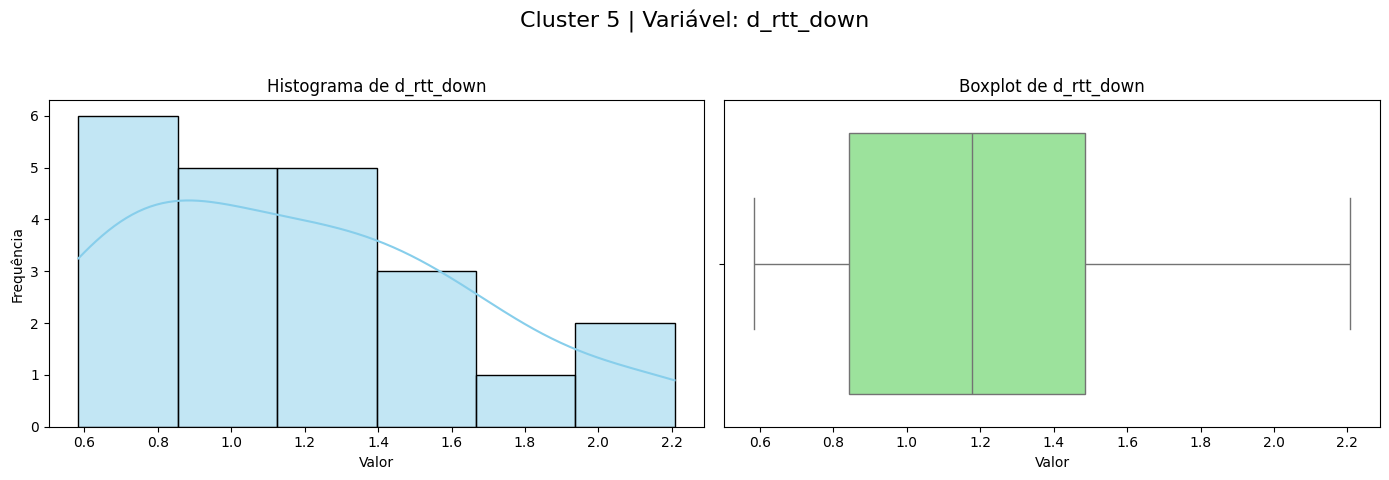

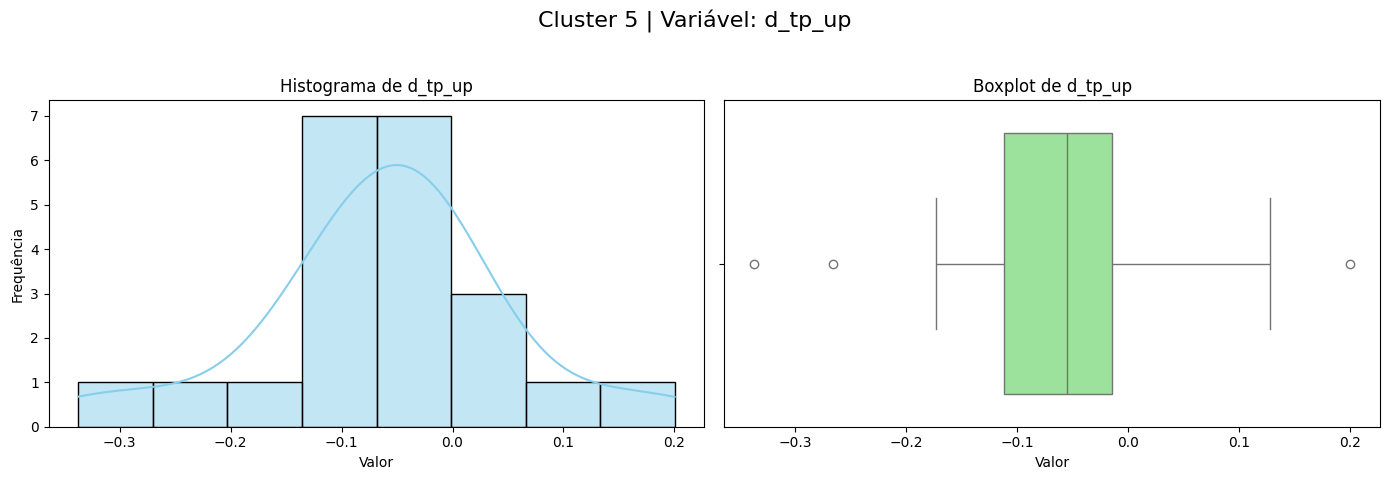

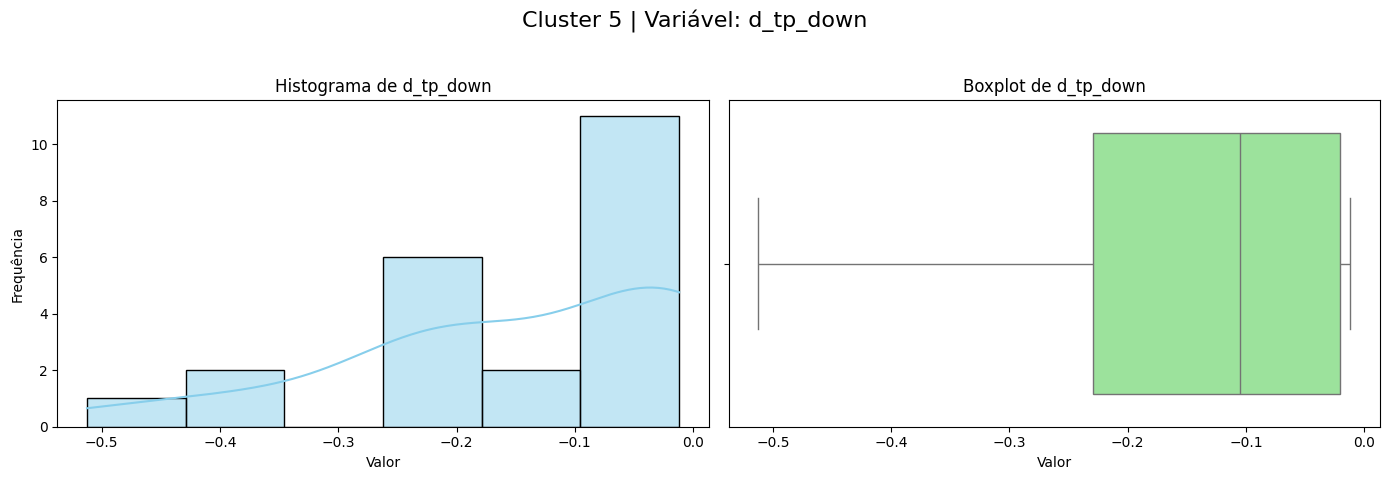

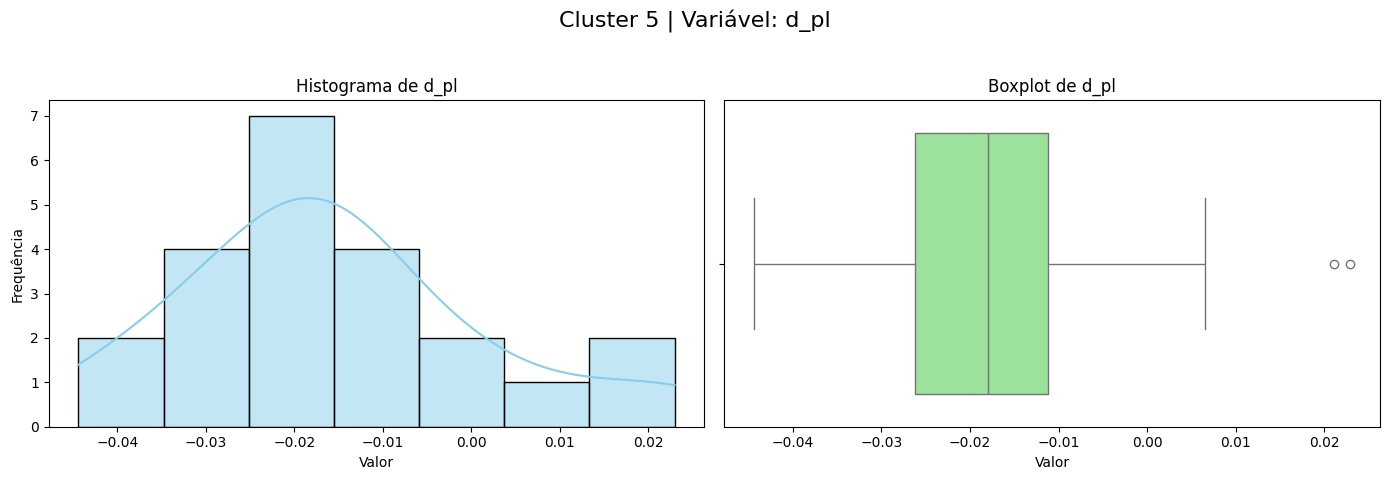

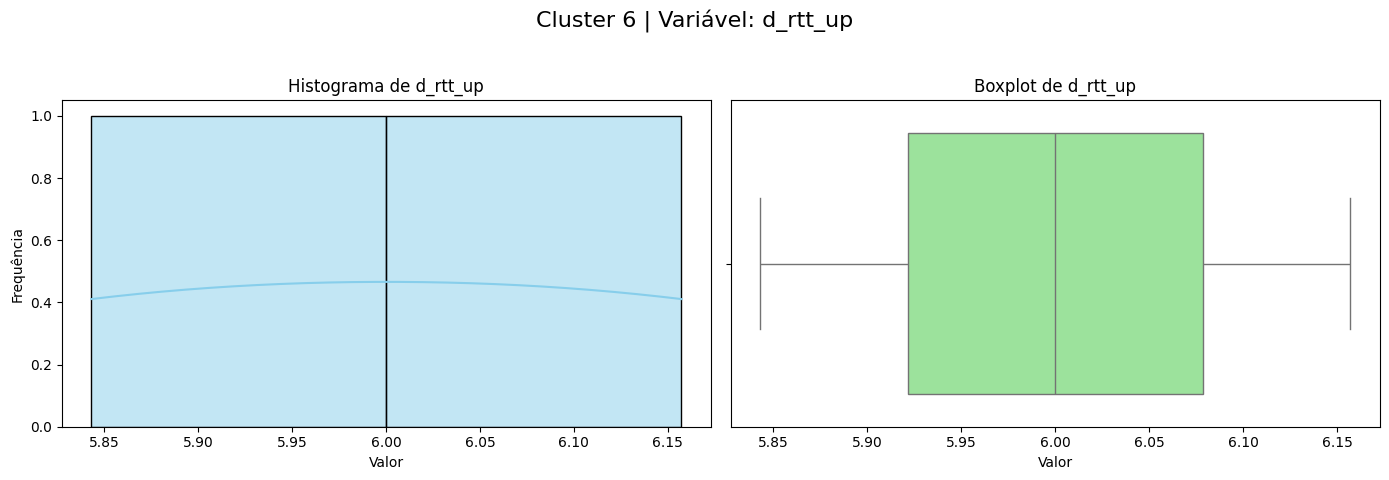

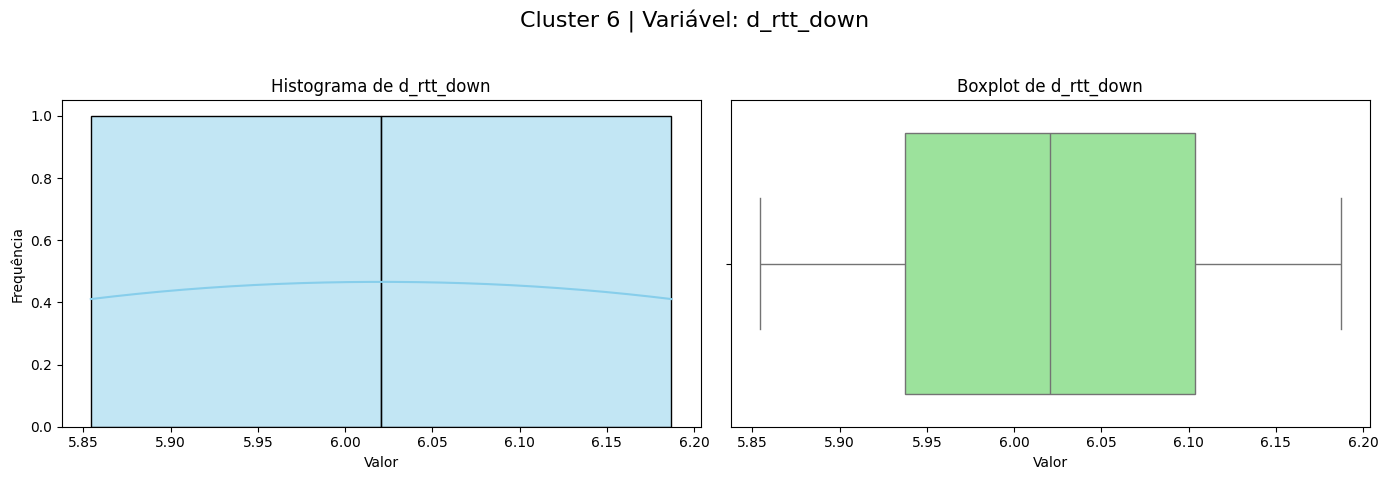

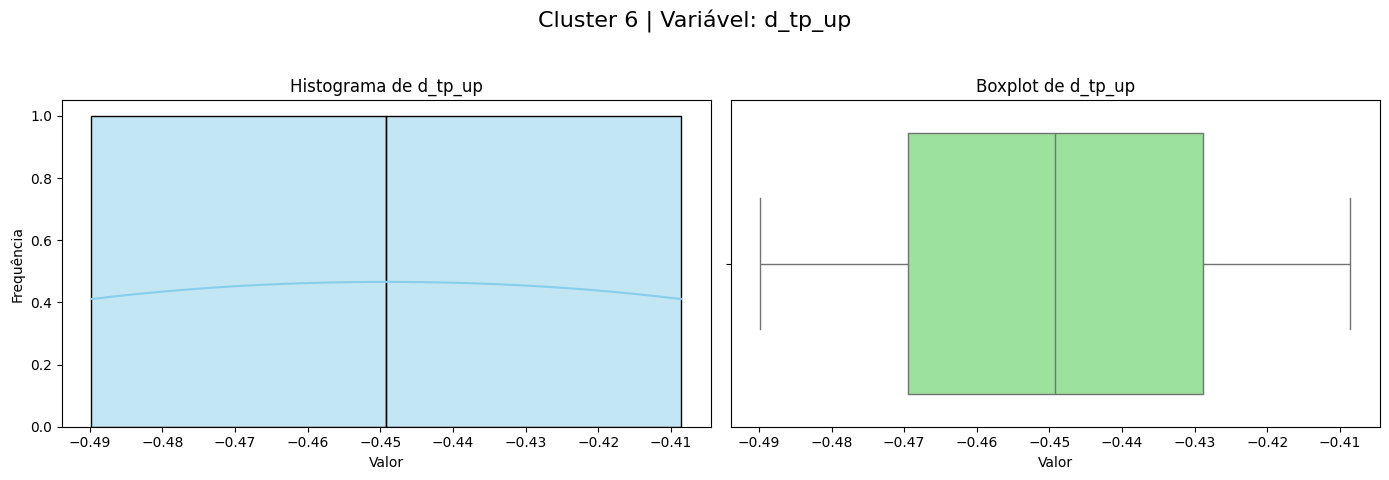

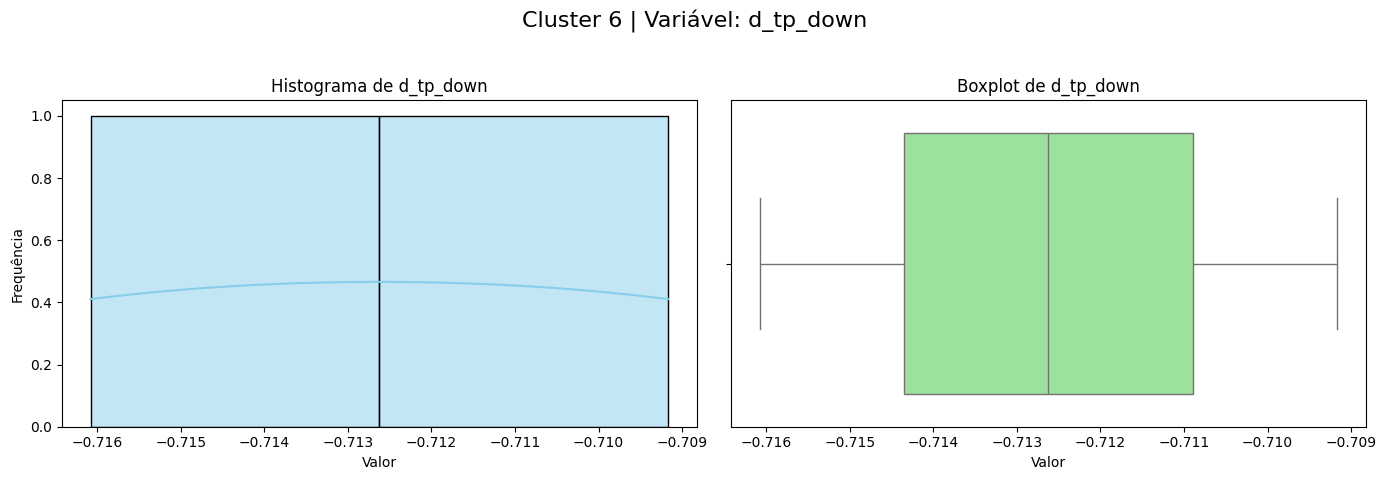

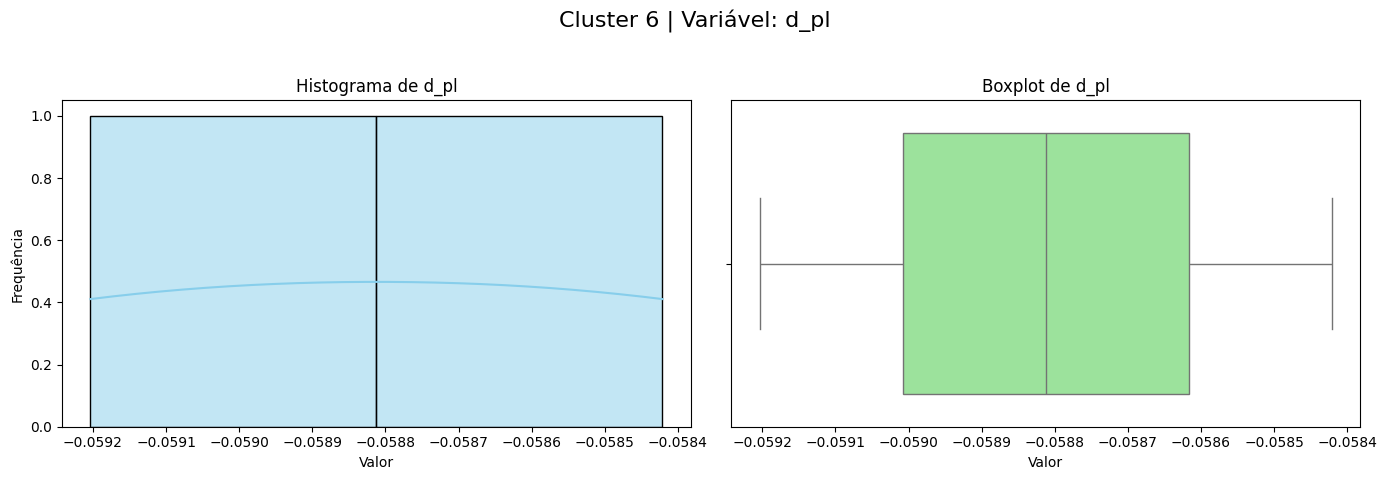

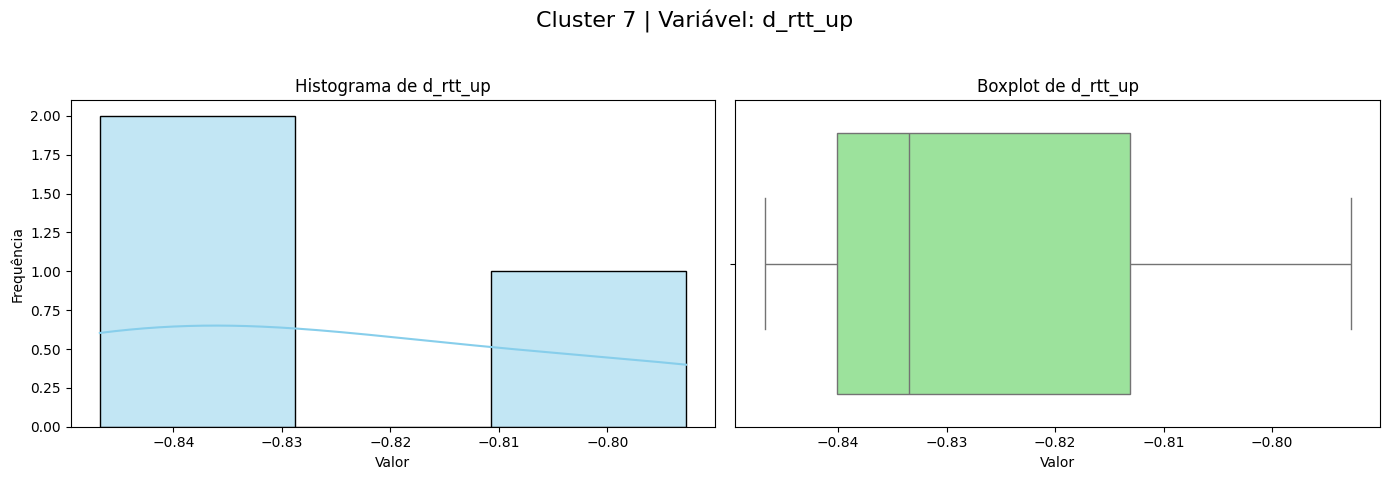

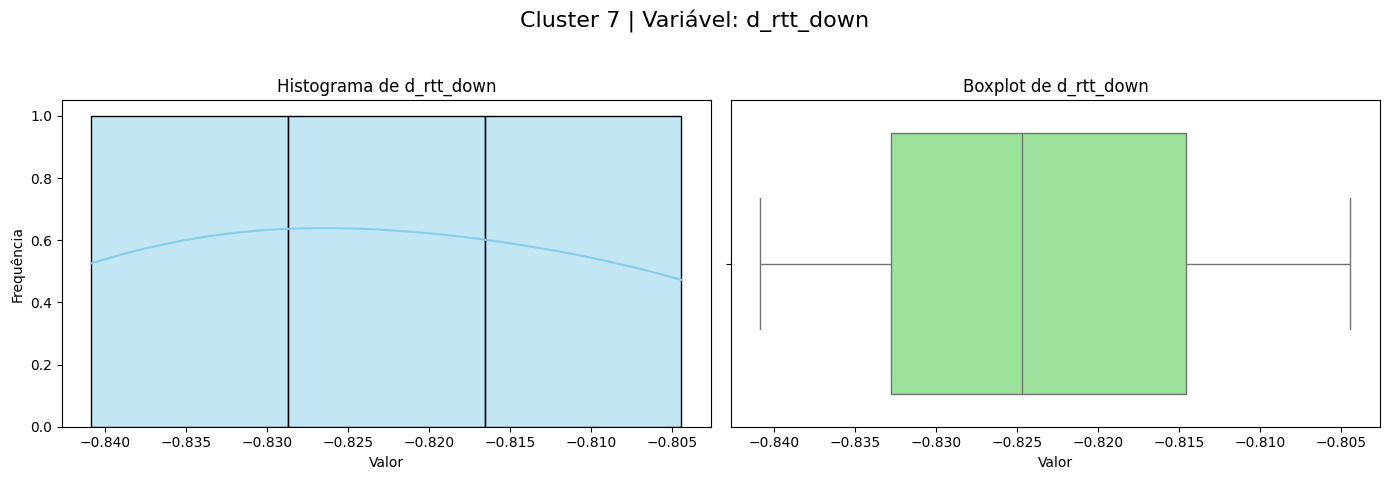

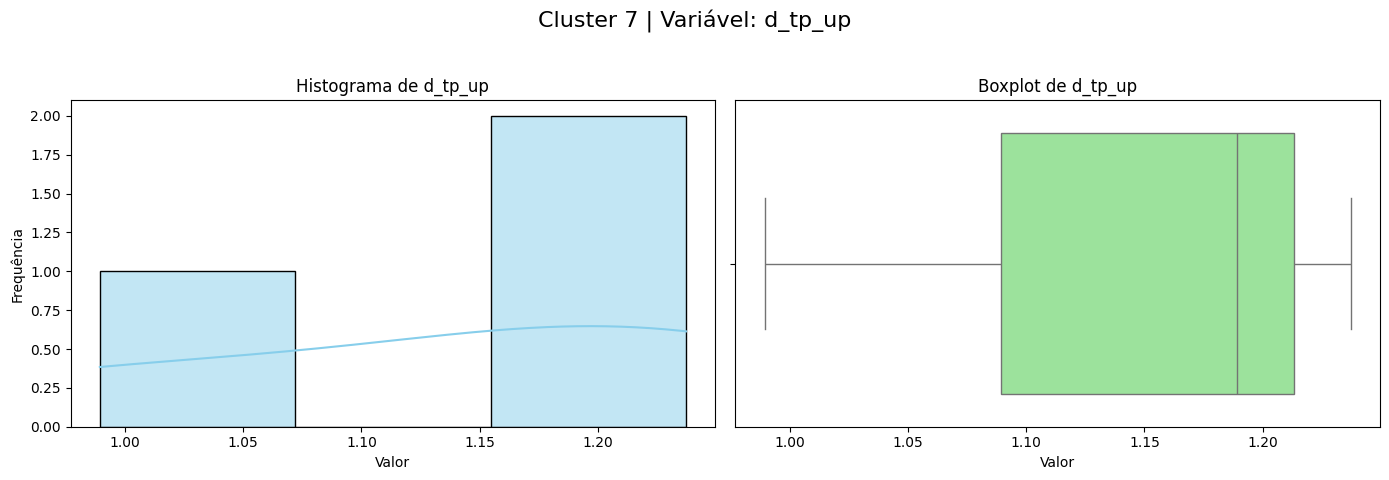

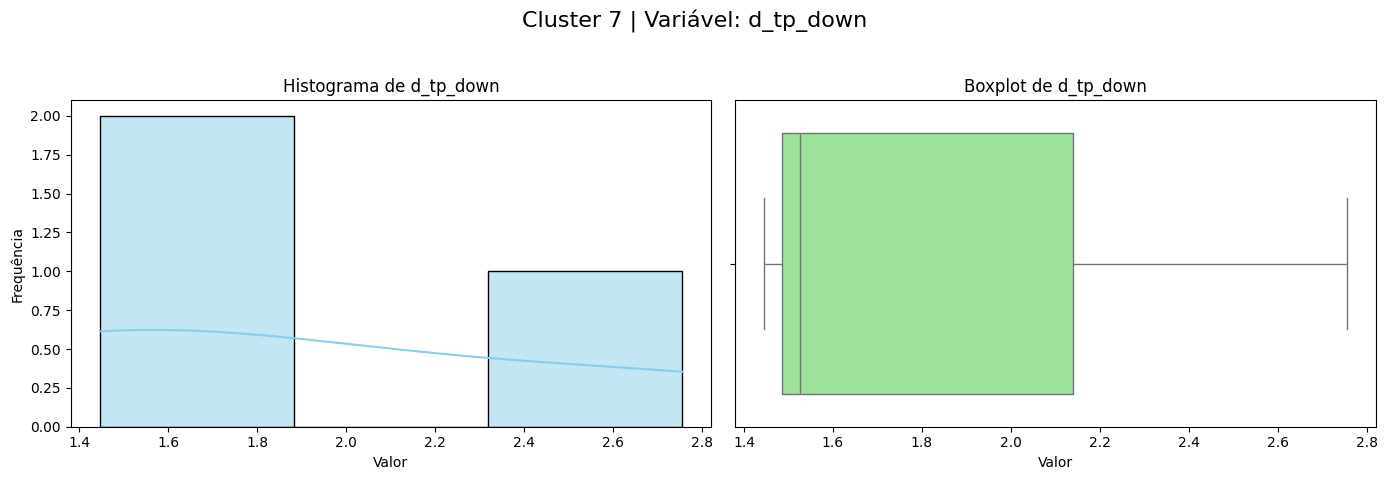

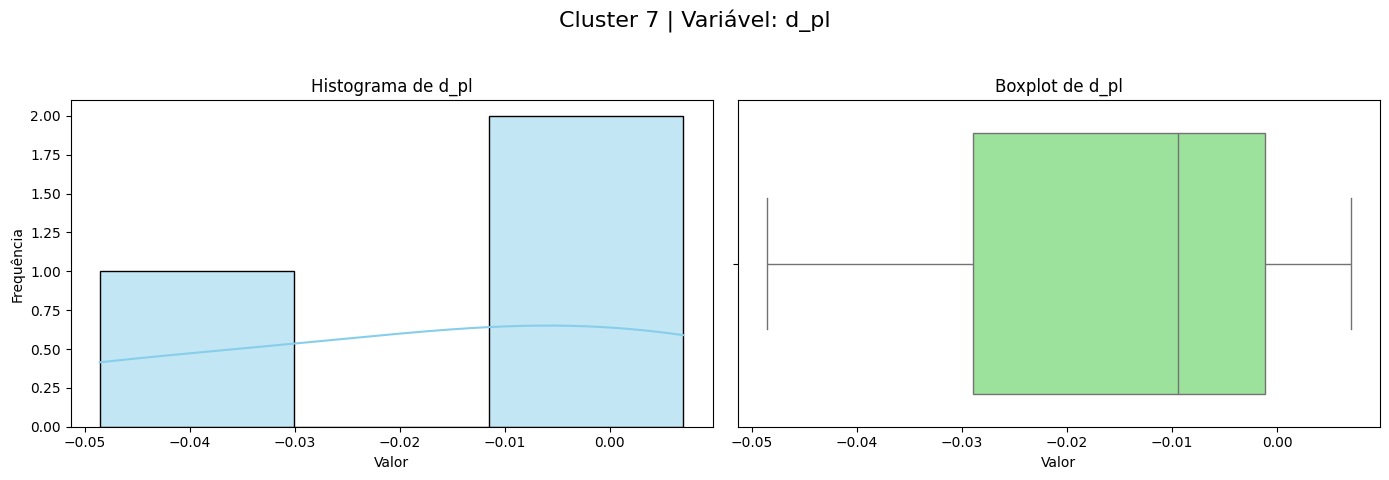

In [ ]:
# Lista das variáveis de interesse
variables = ['d_rtt_up', 'd_rtt_down', 'd_tp_up', 'd_tp_down', 'd_pl']

# Obtendo os clusters únicos presentes no DataFrame
clusters = df_clusters['cluster'].unique()

# Ordenar os clusters para garantir uma apresentação consistente
clusters.sort()



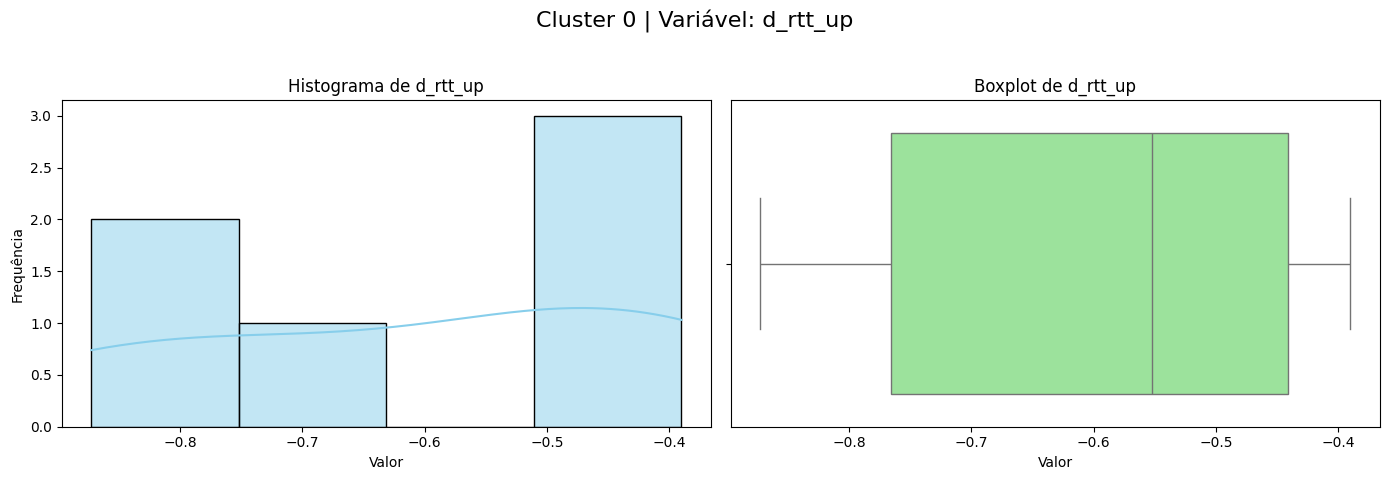

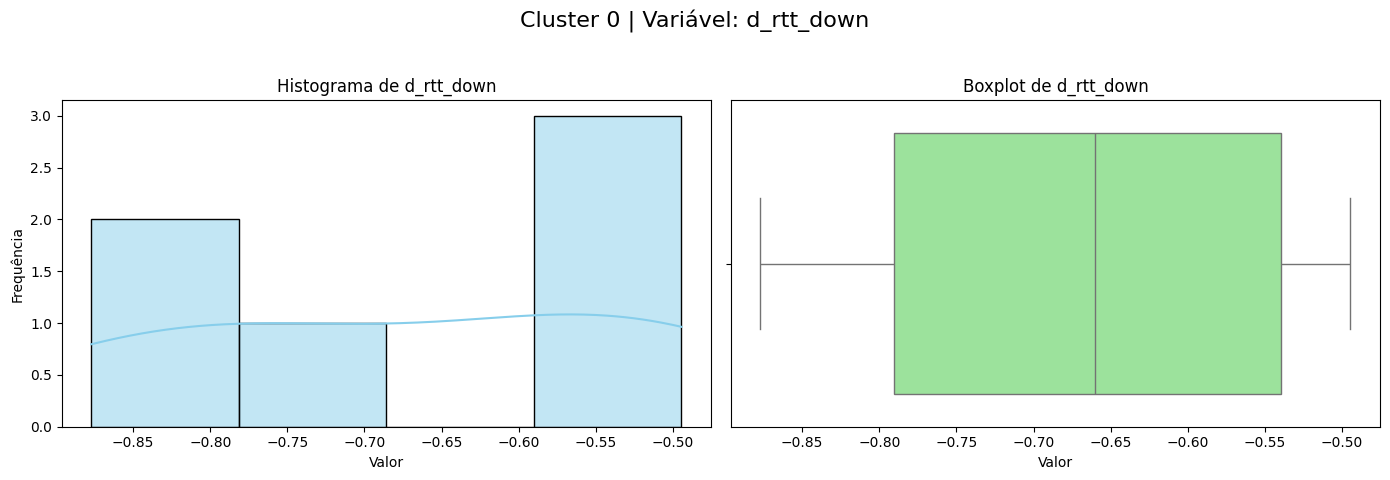

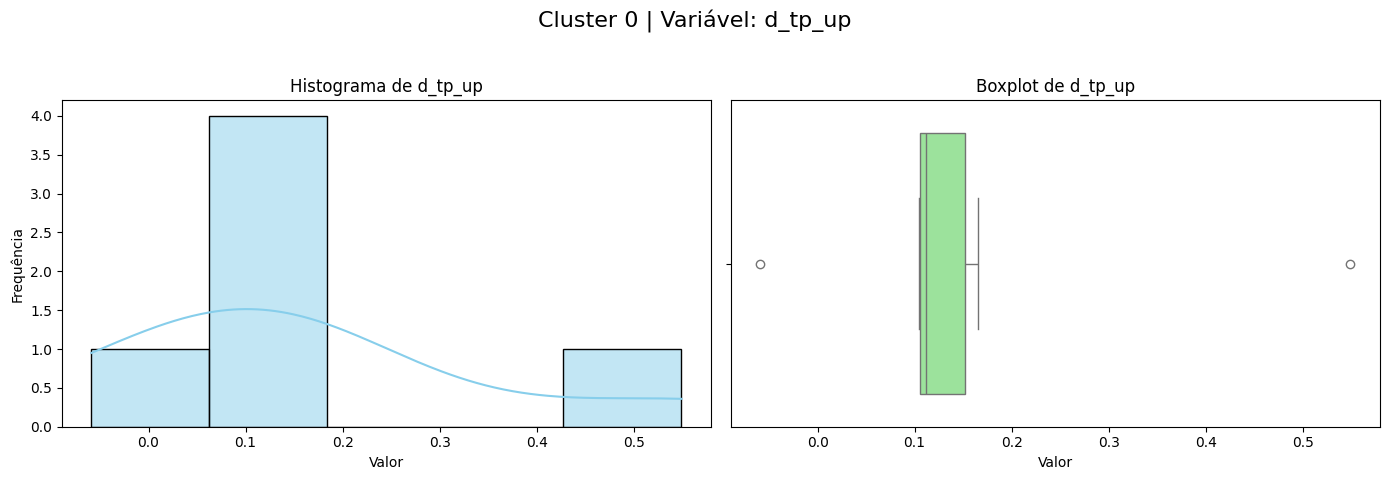

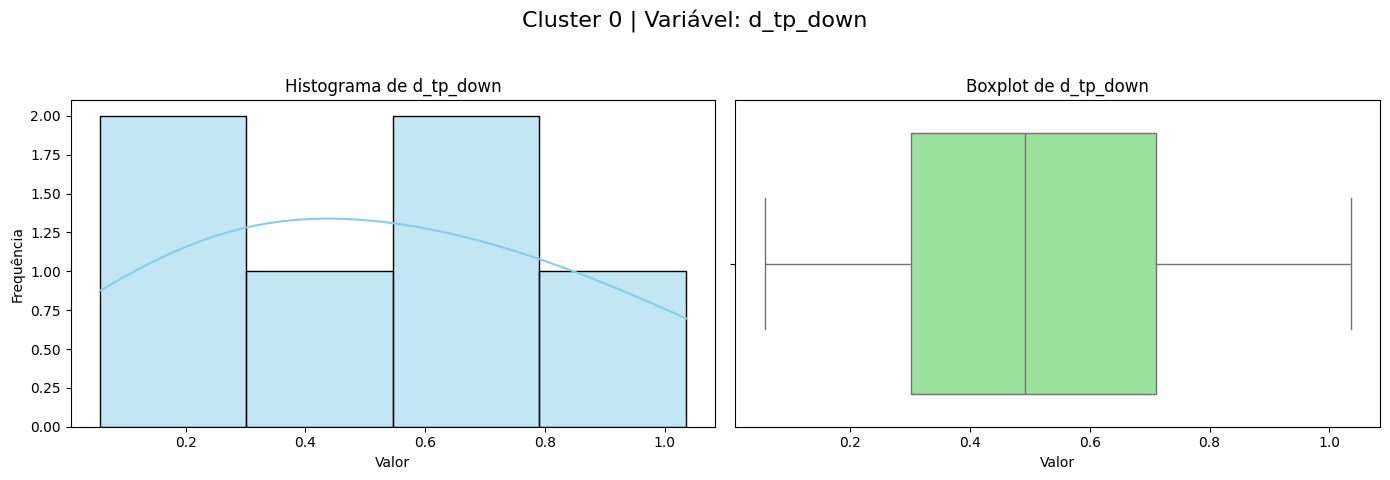

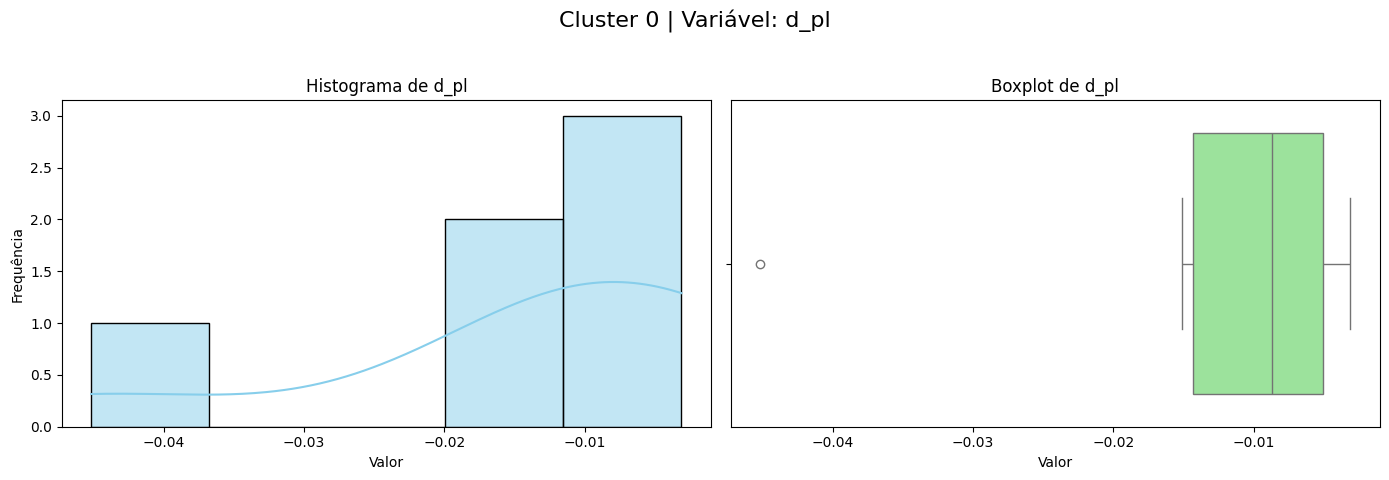

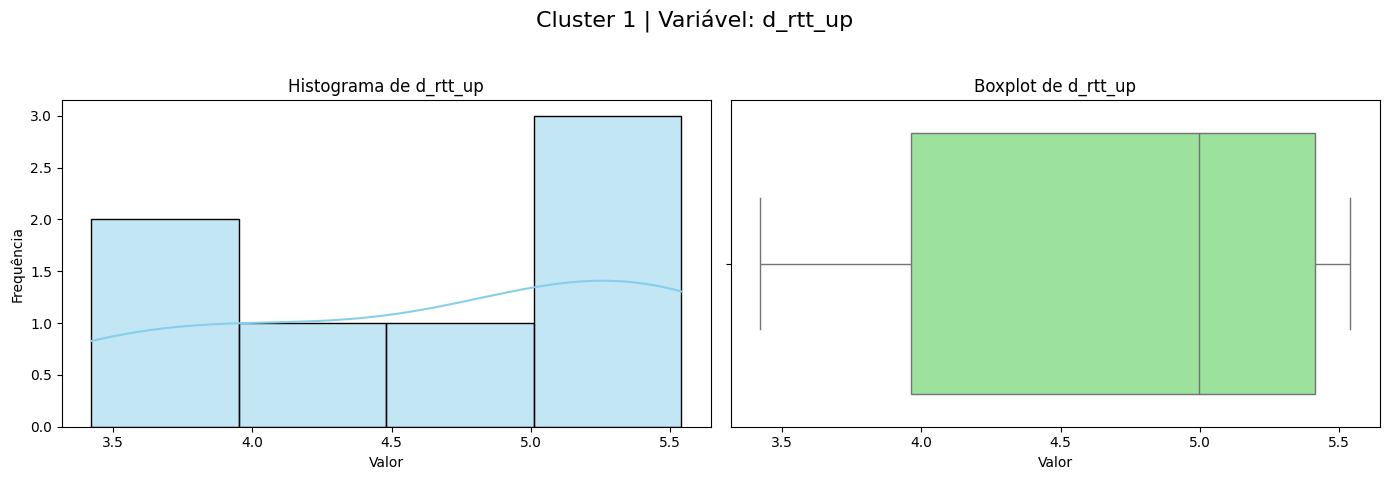

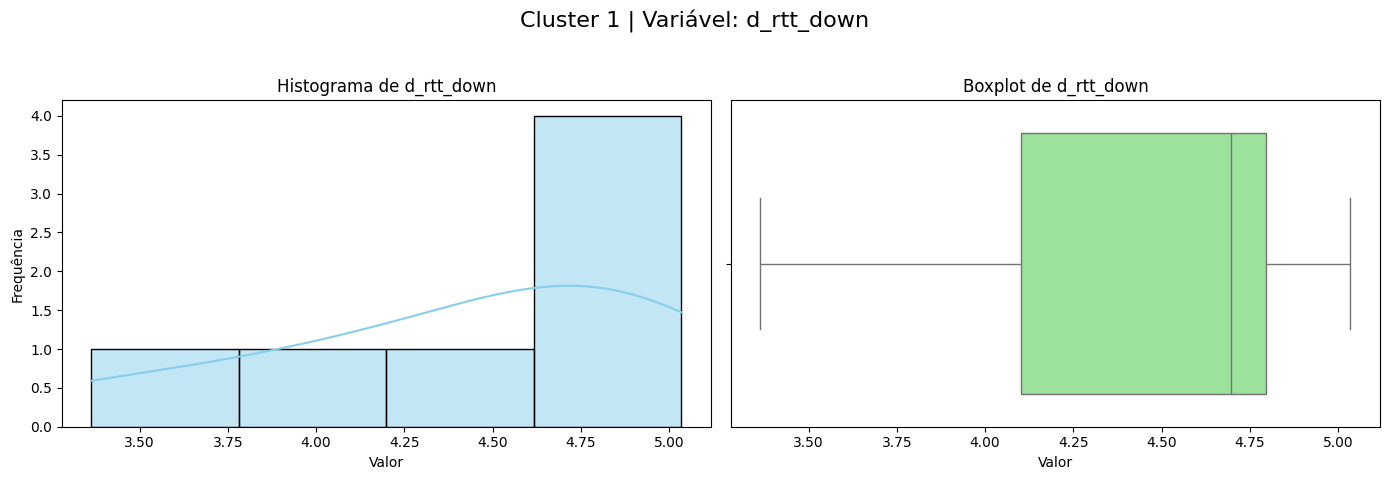

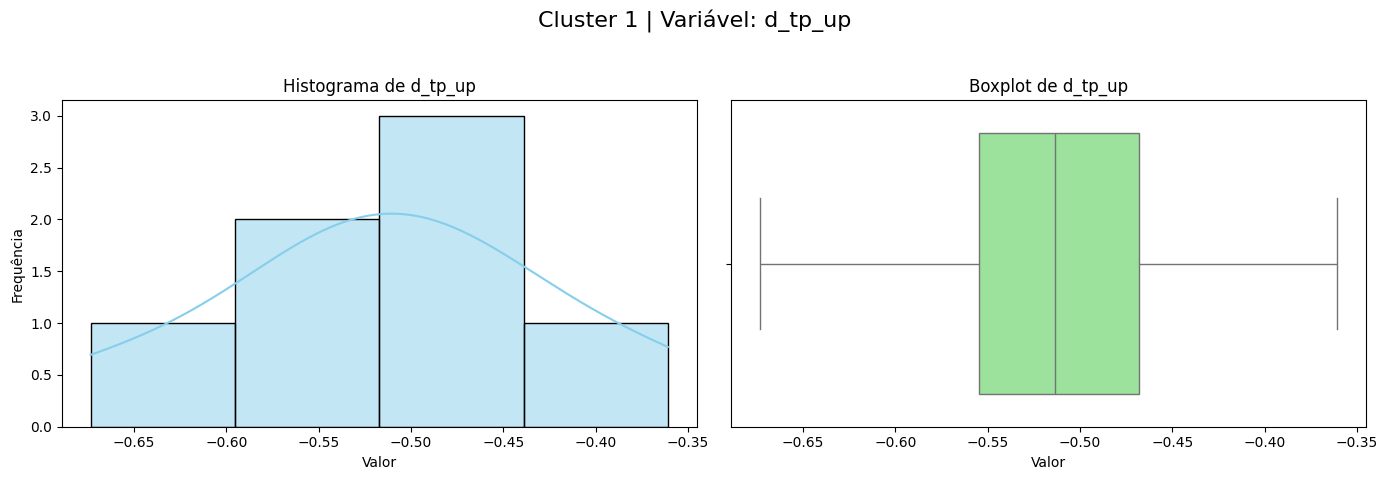

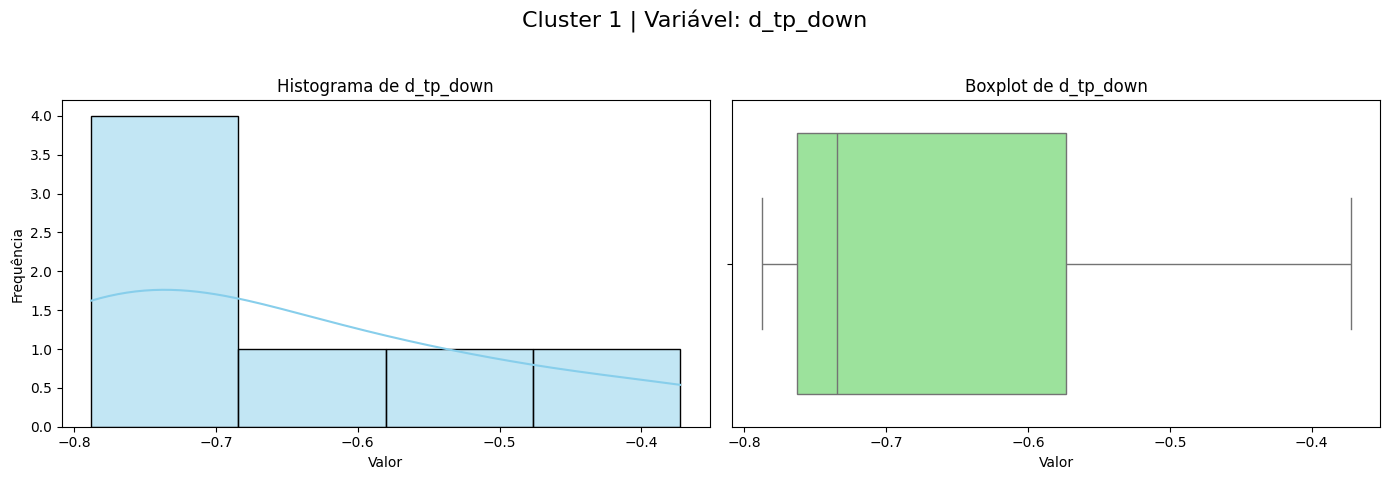

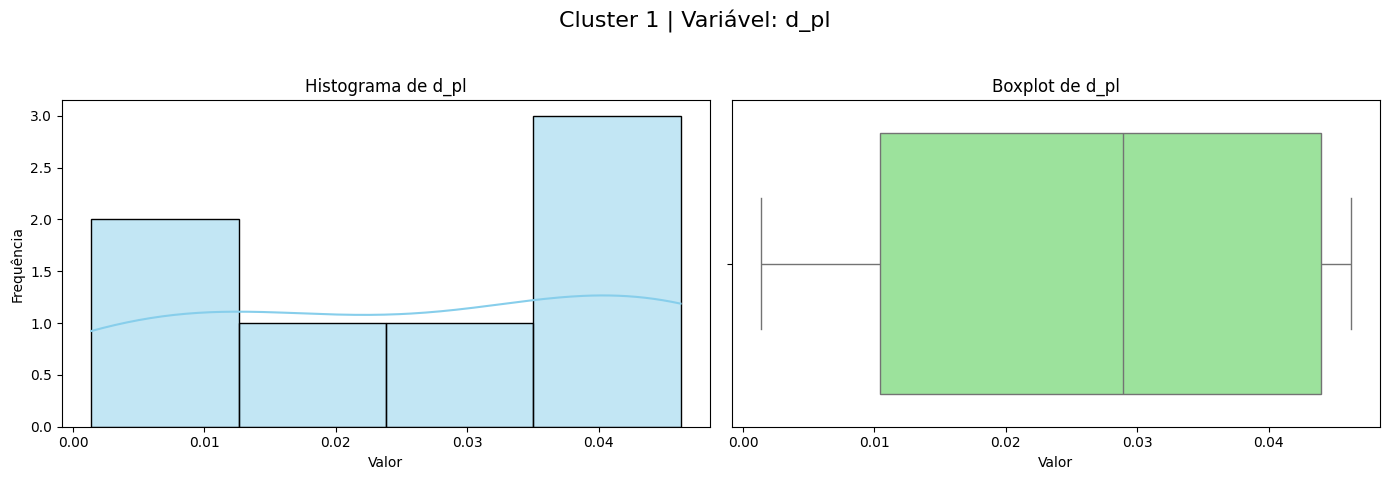

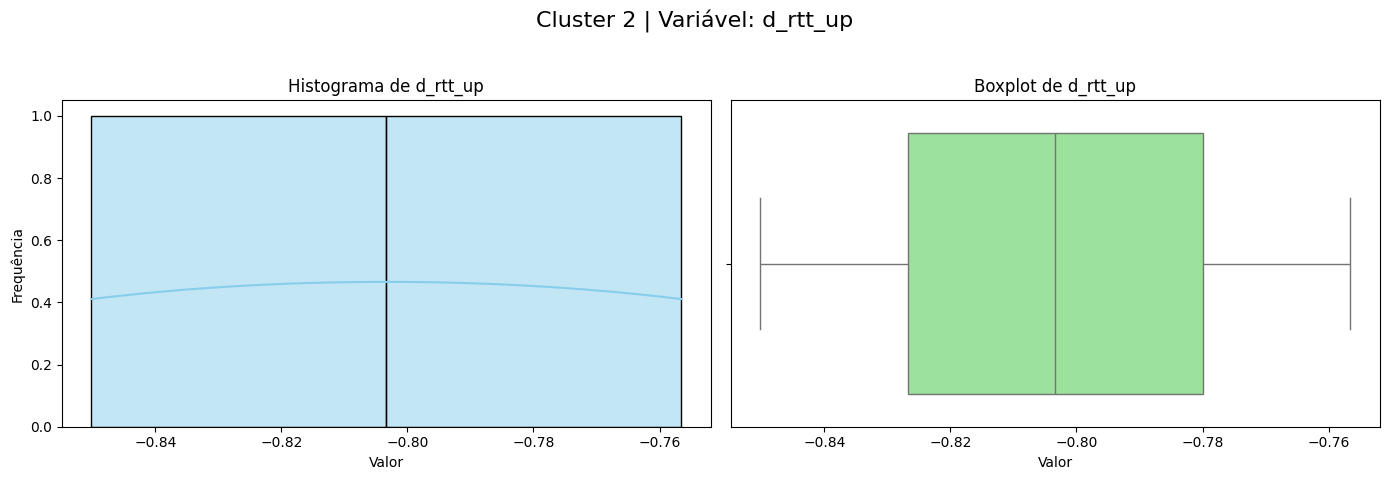

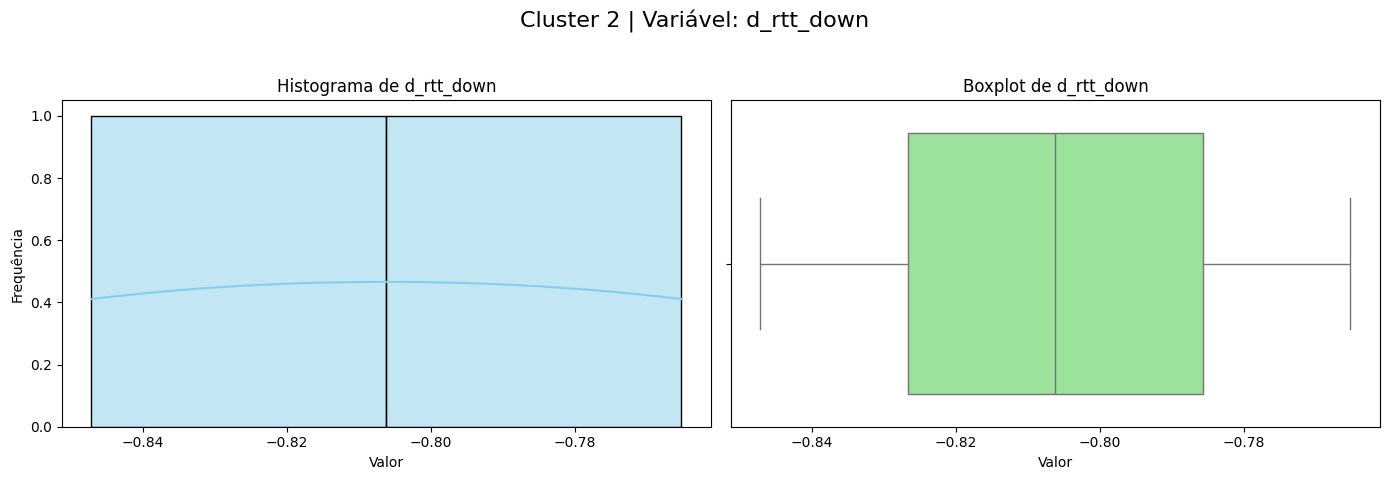

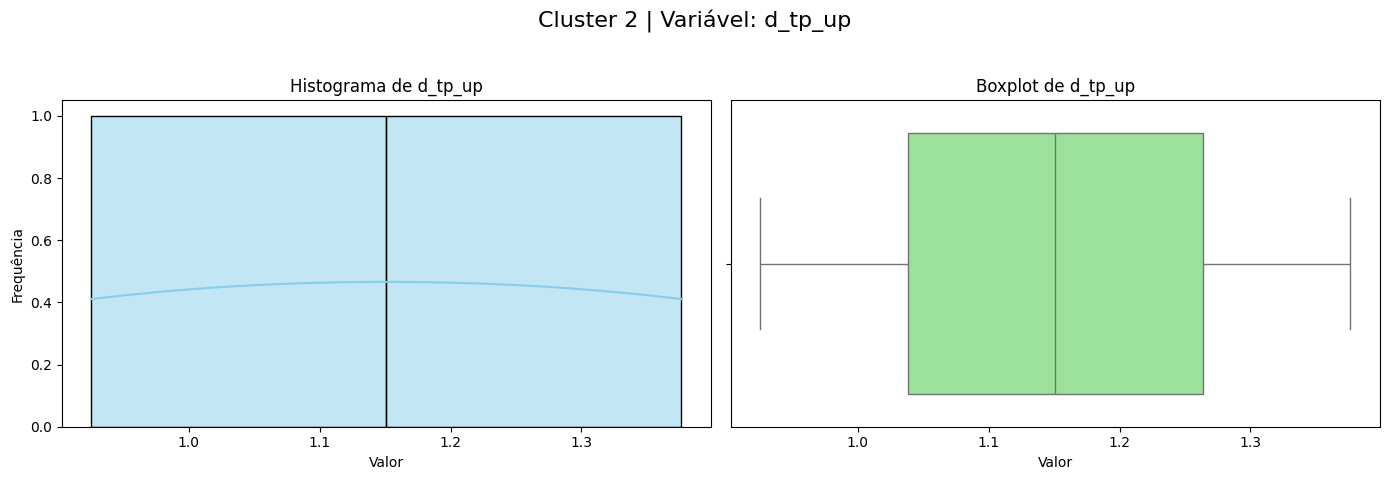

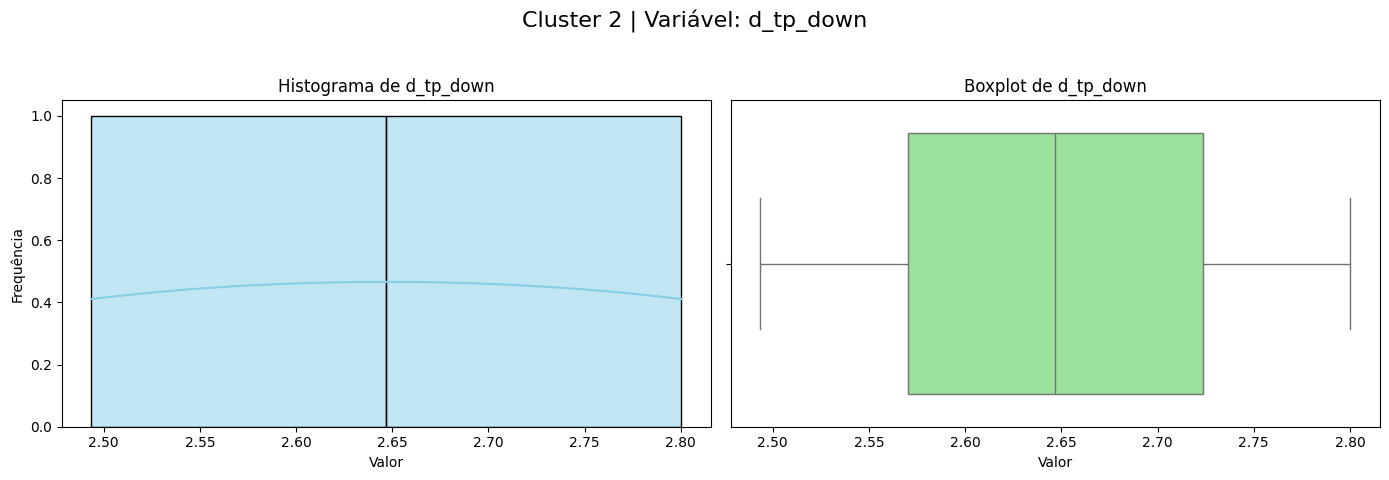

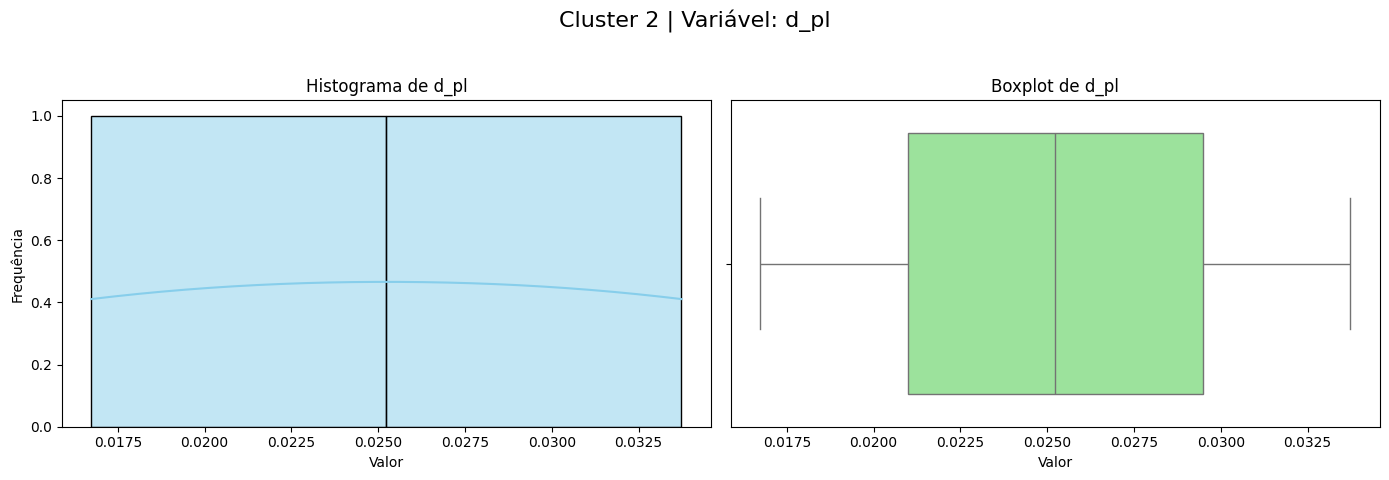

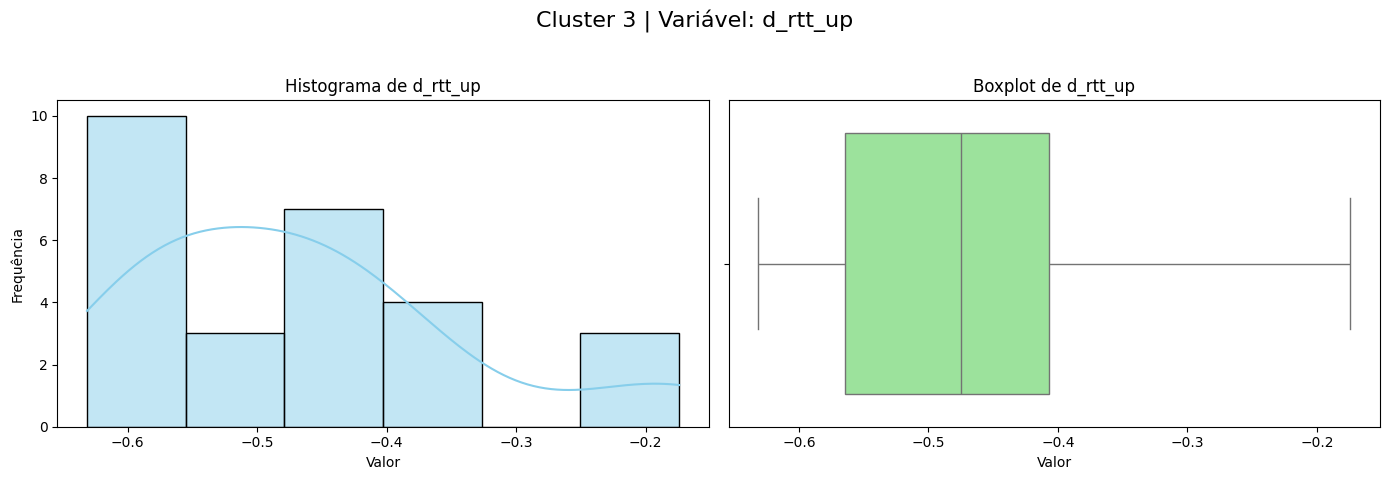

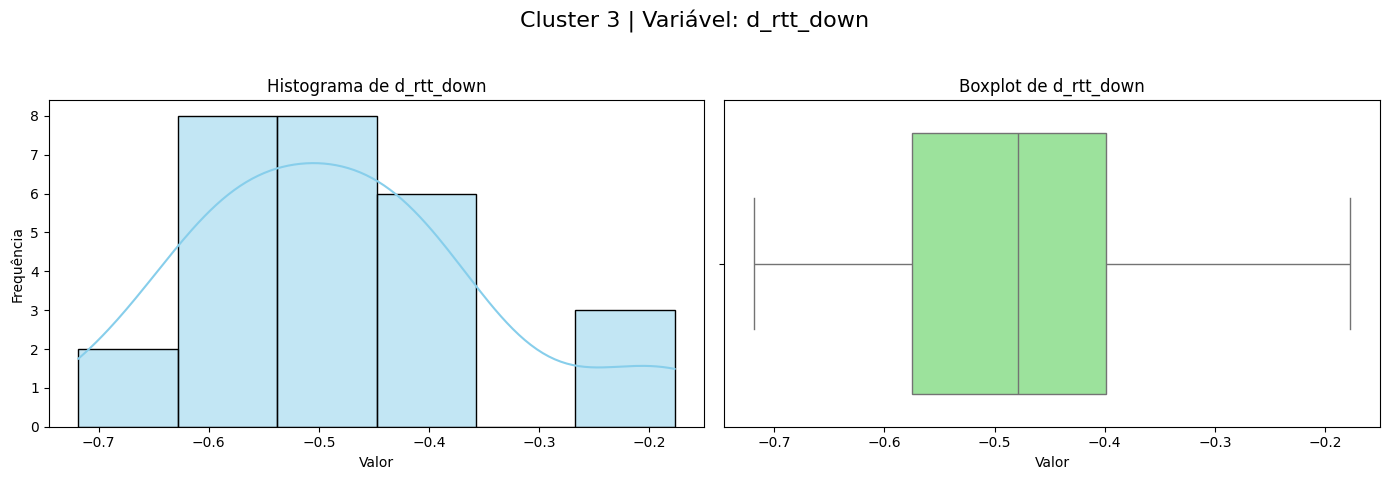

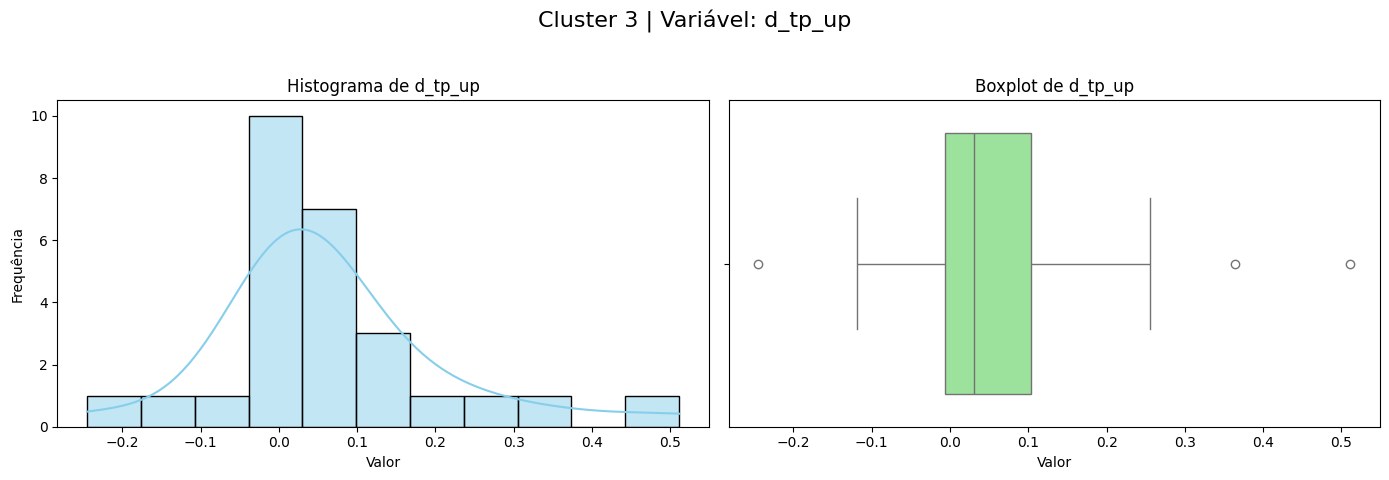

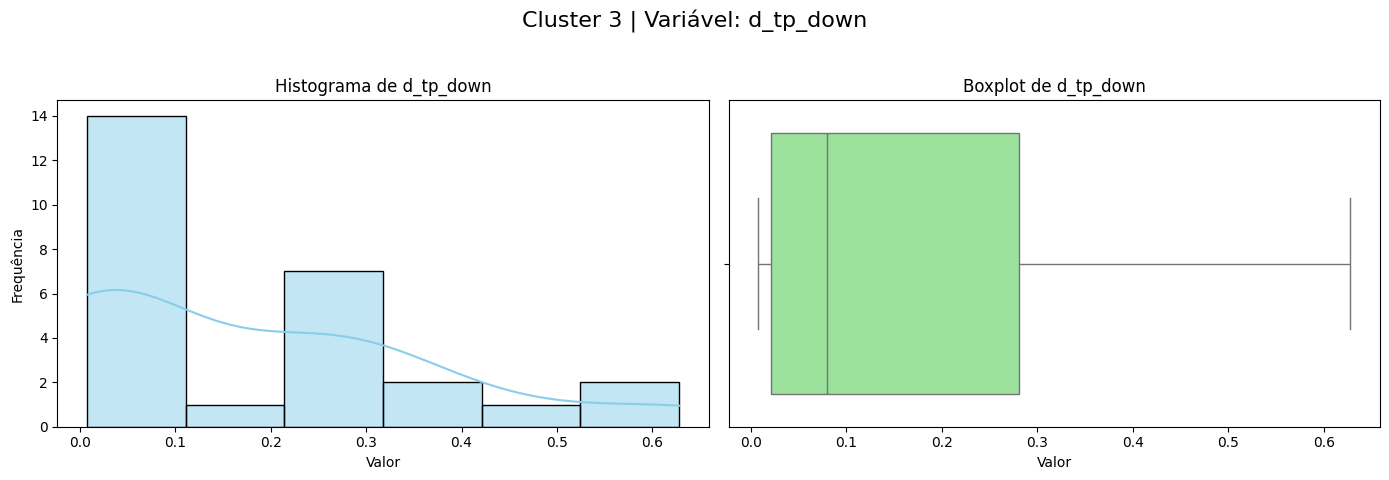

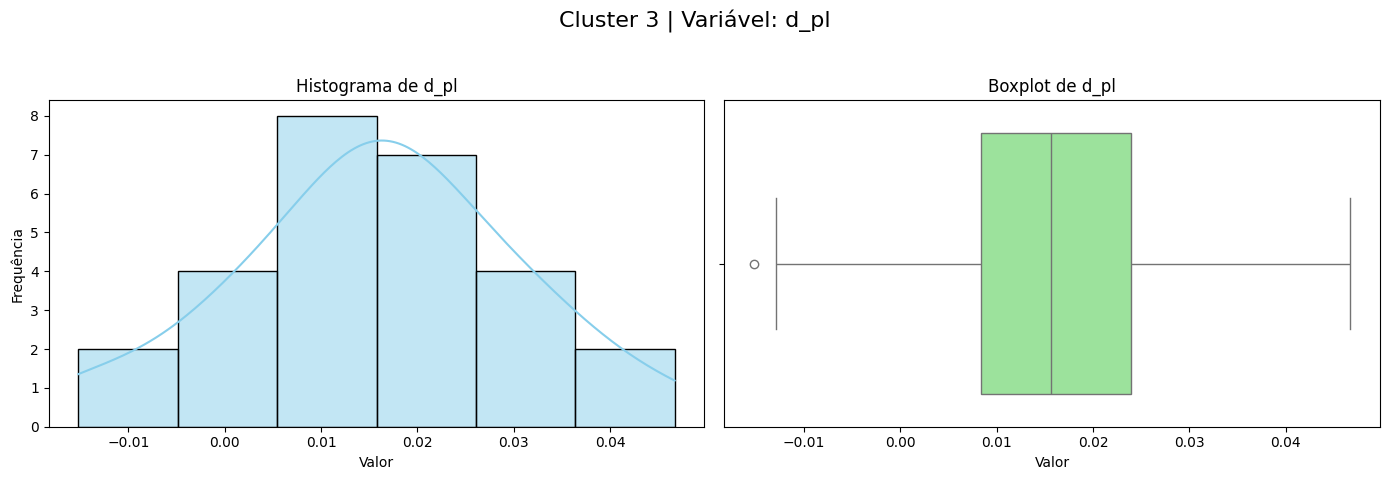

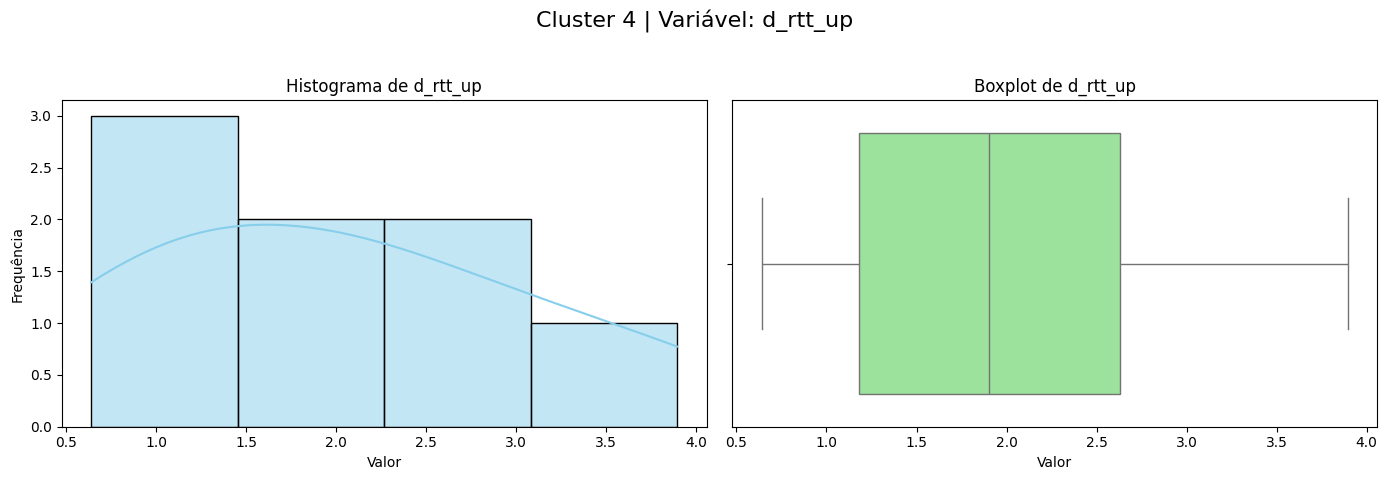

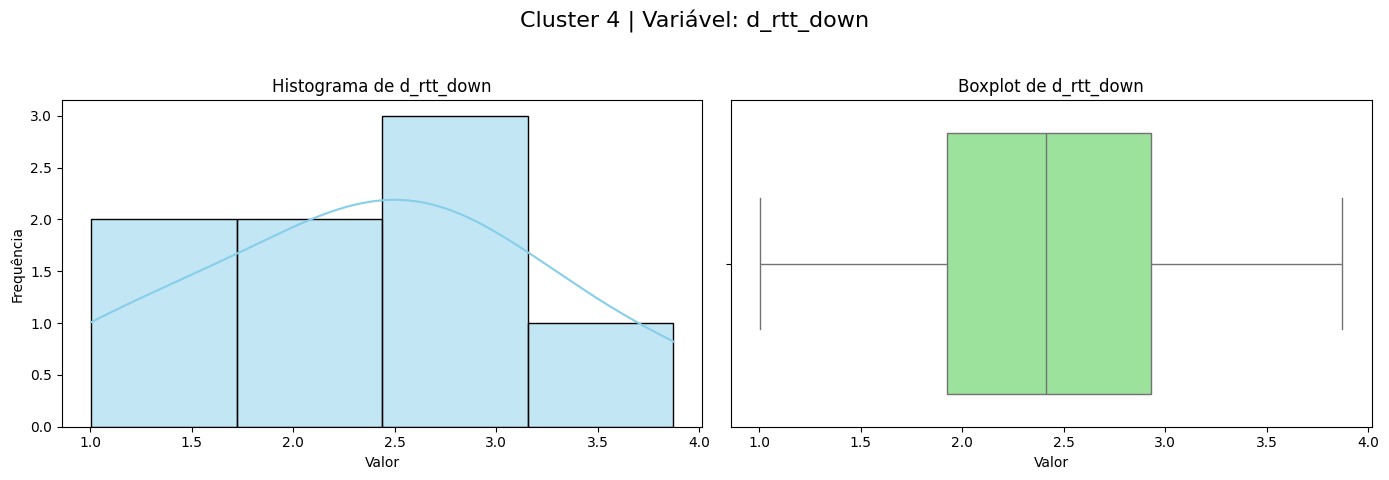

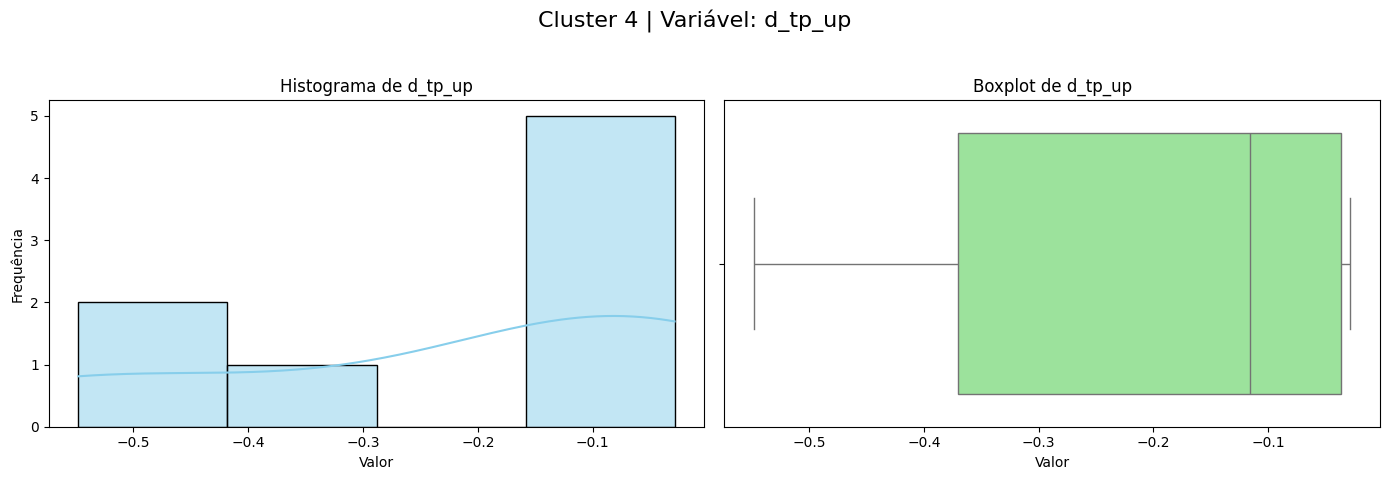

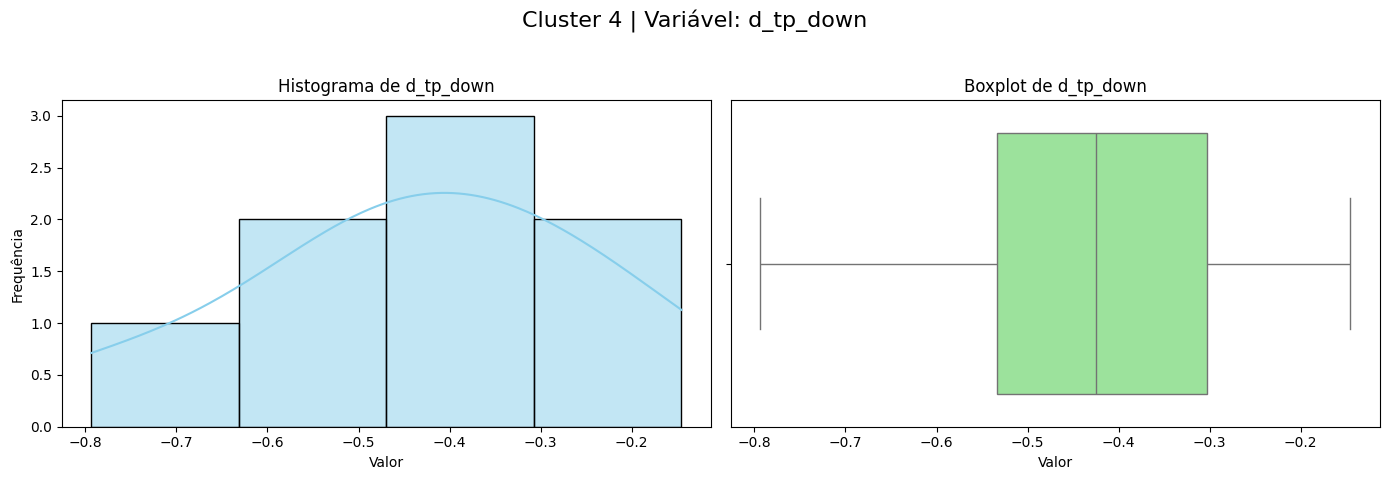

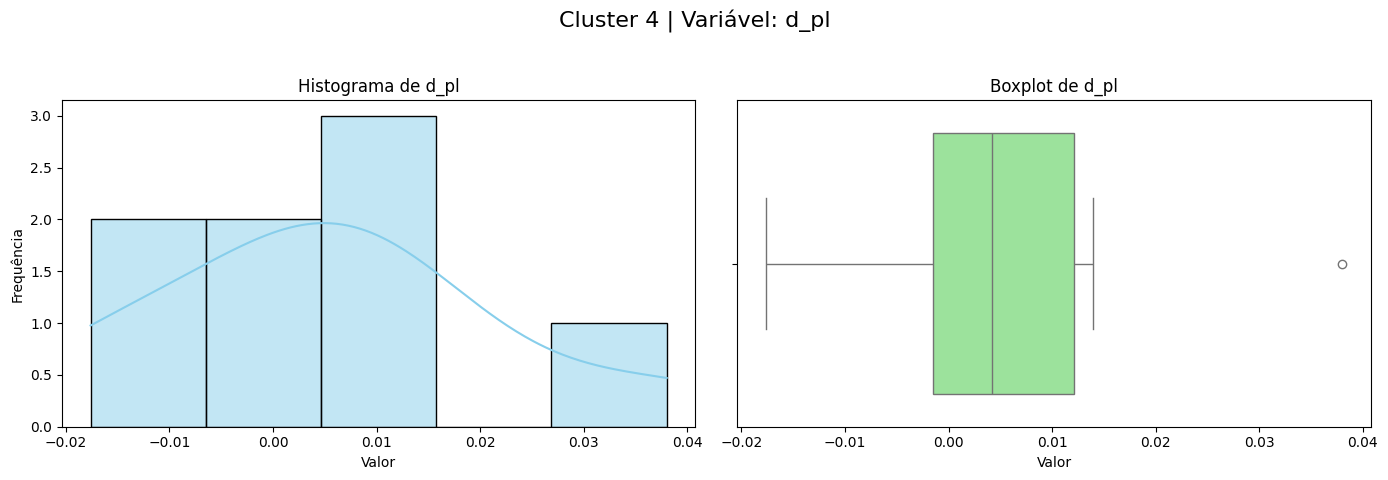

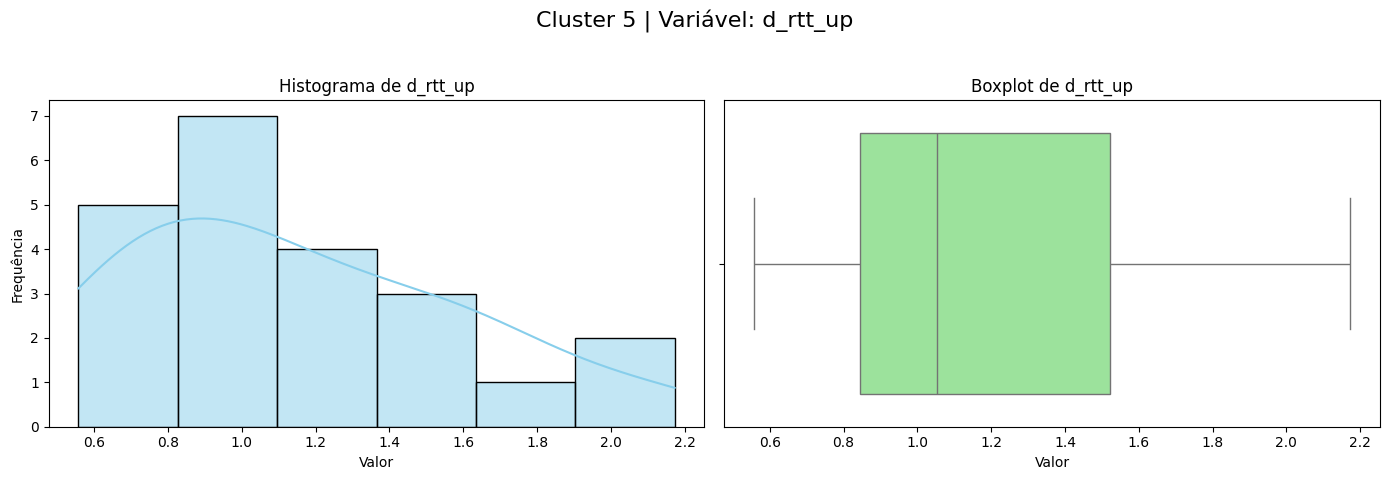

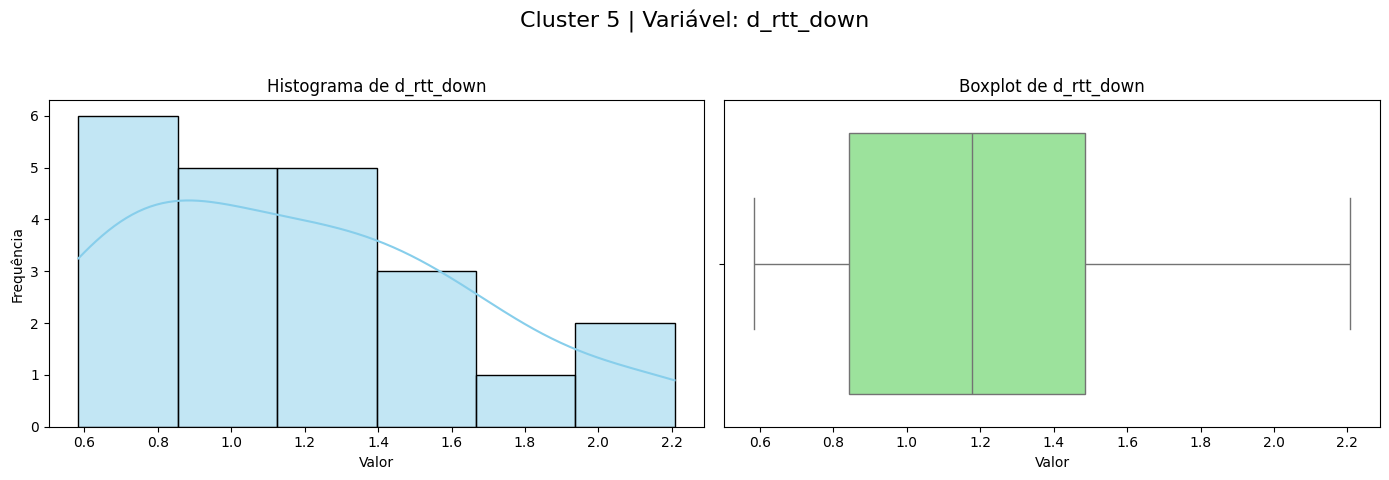

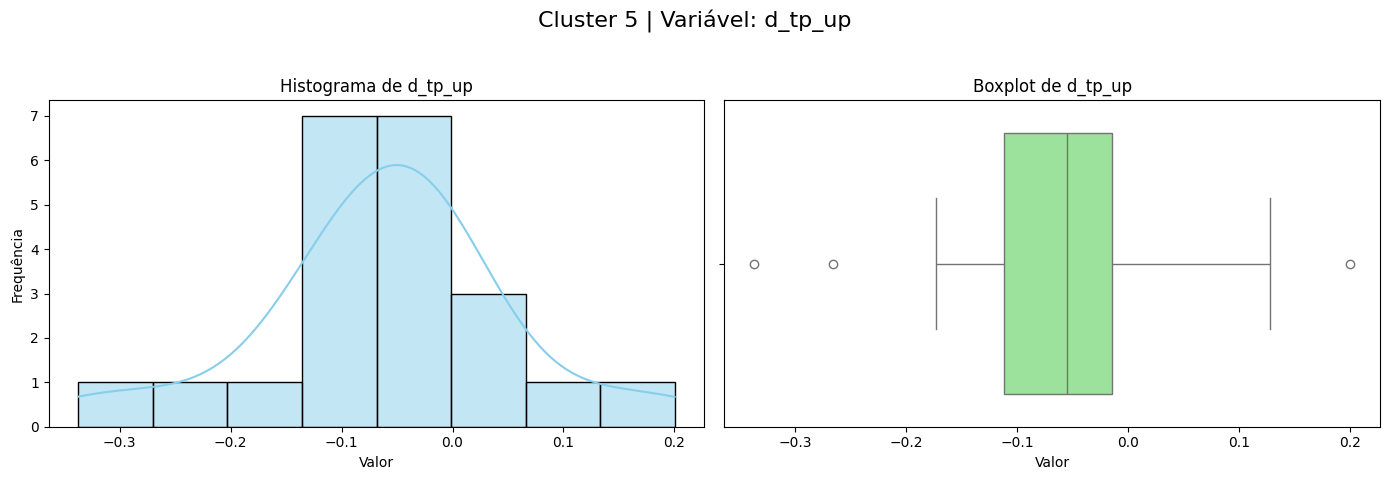

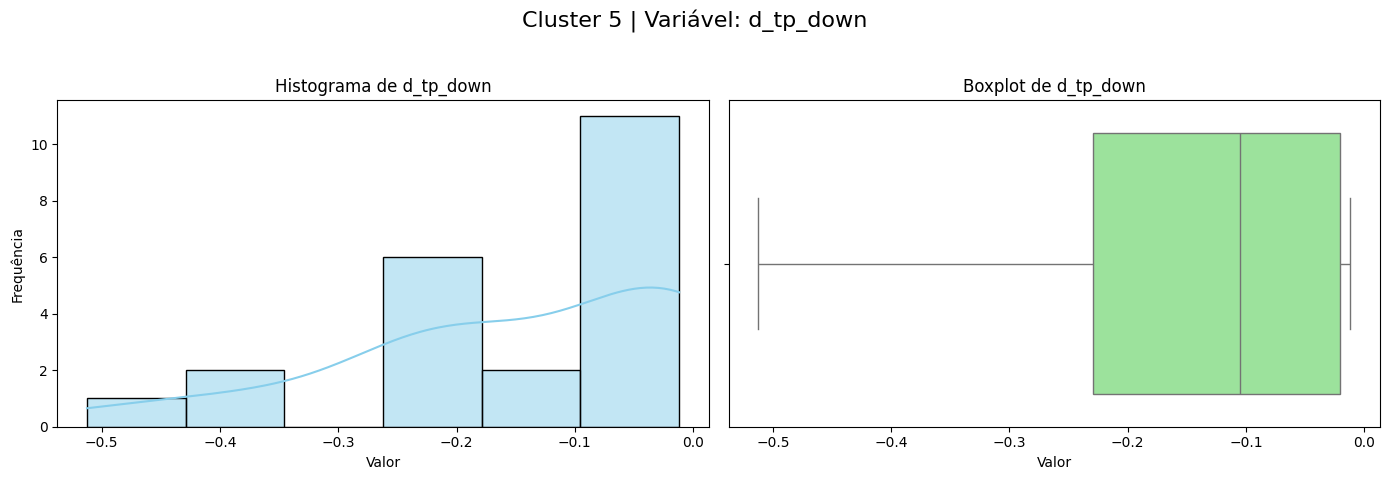

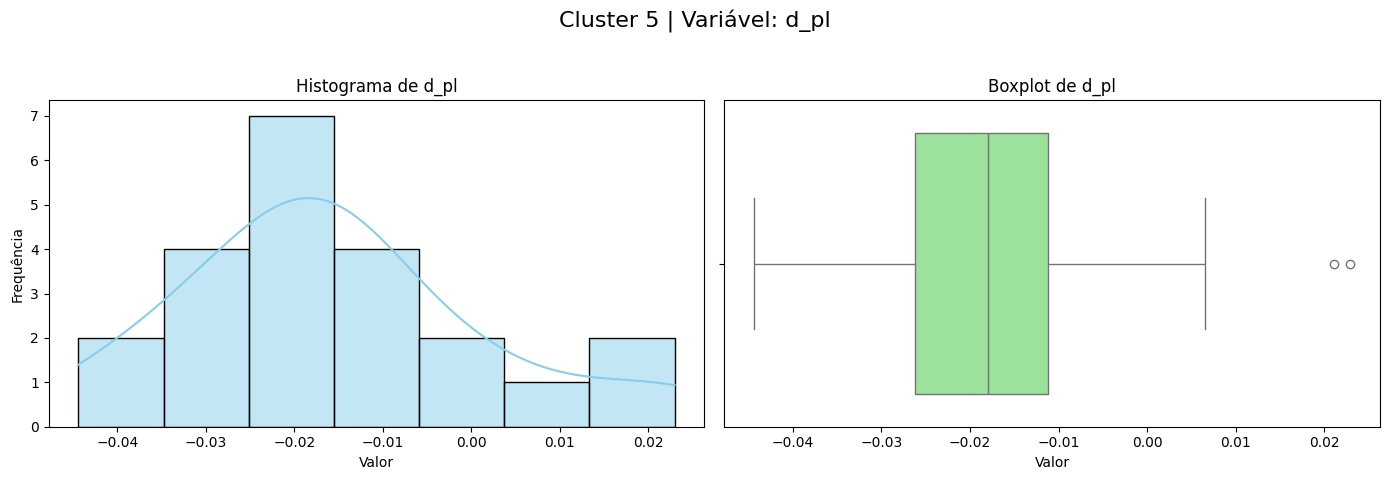

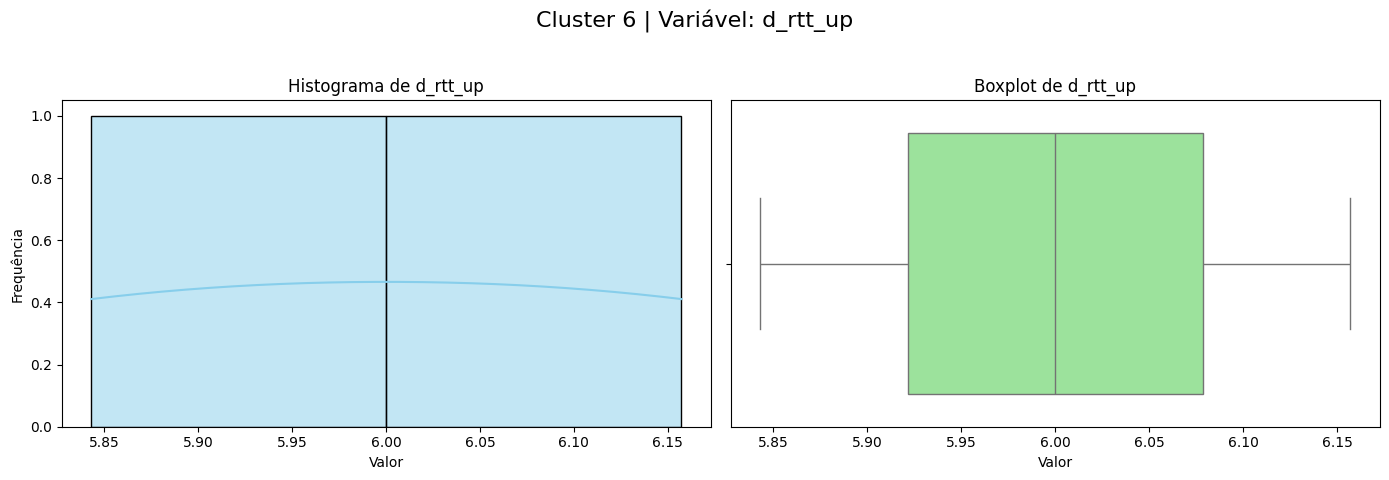

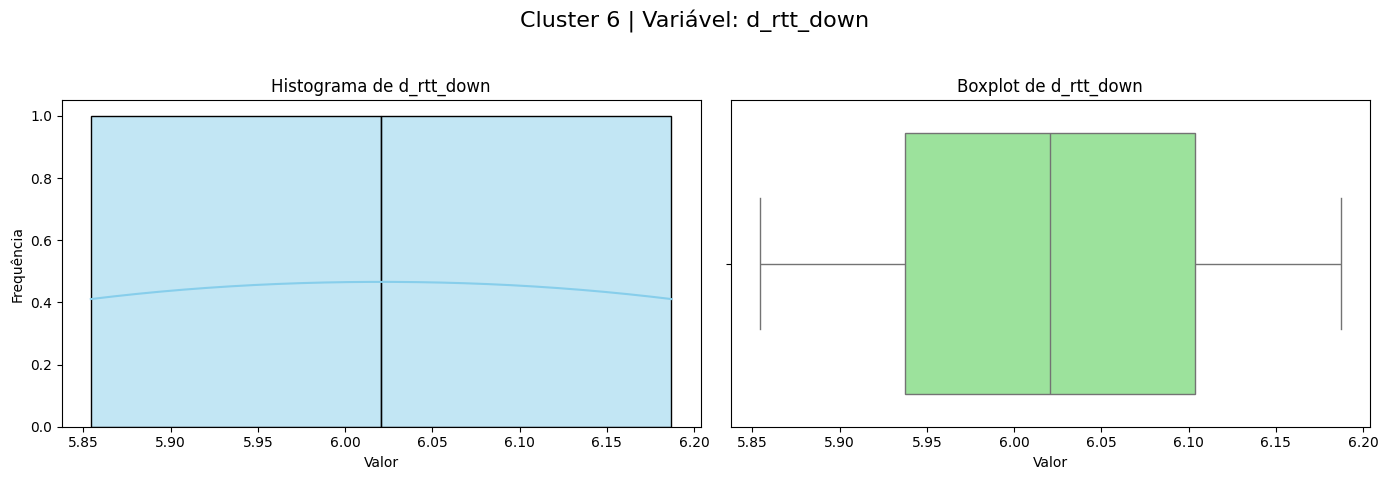

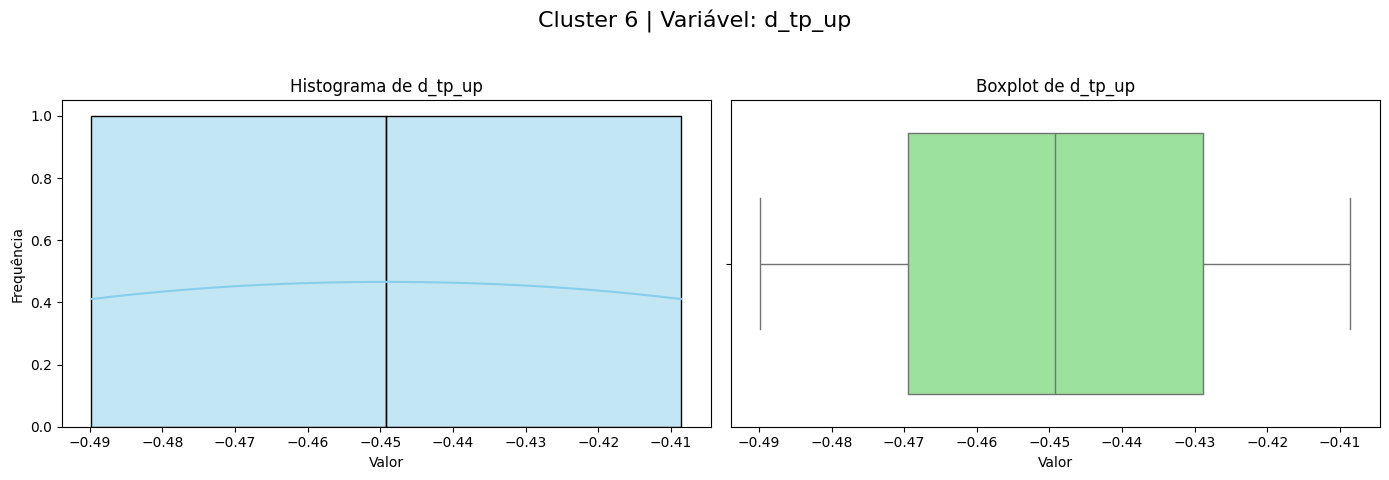

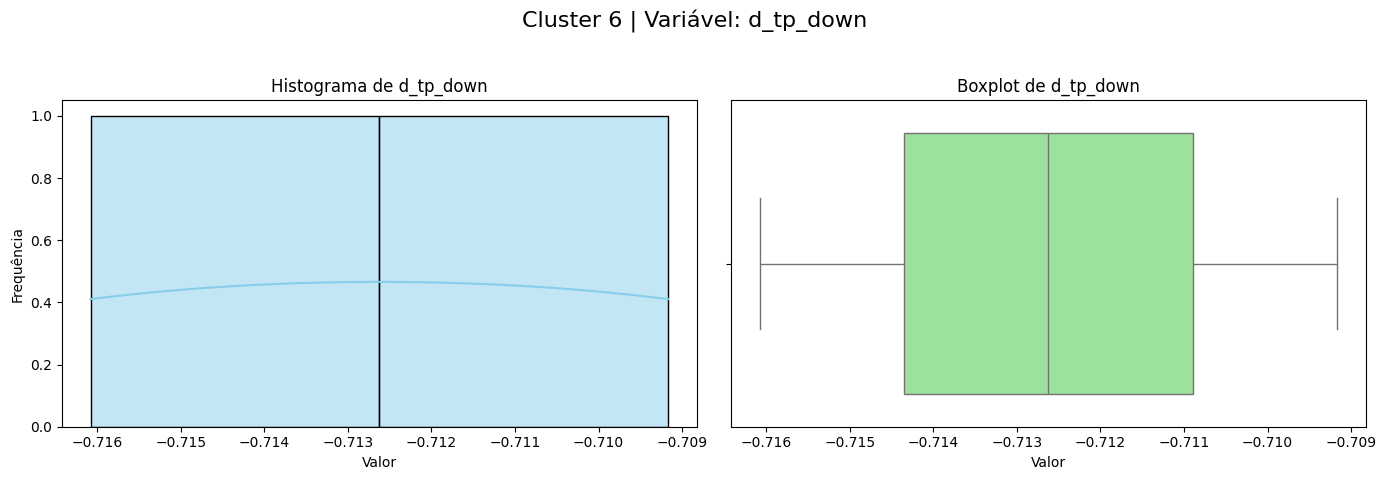

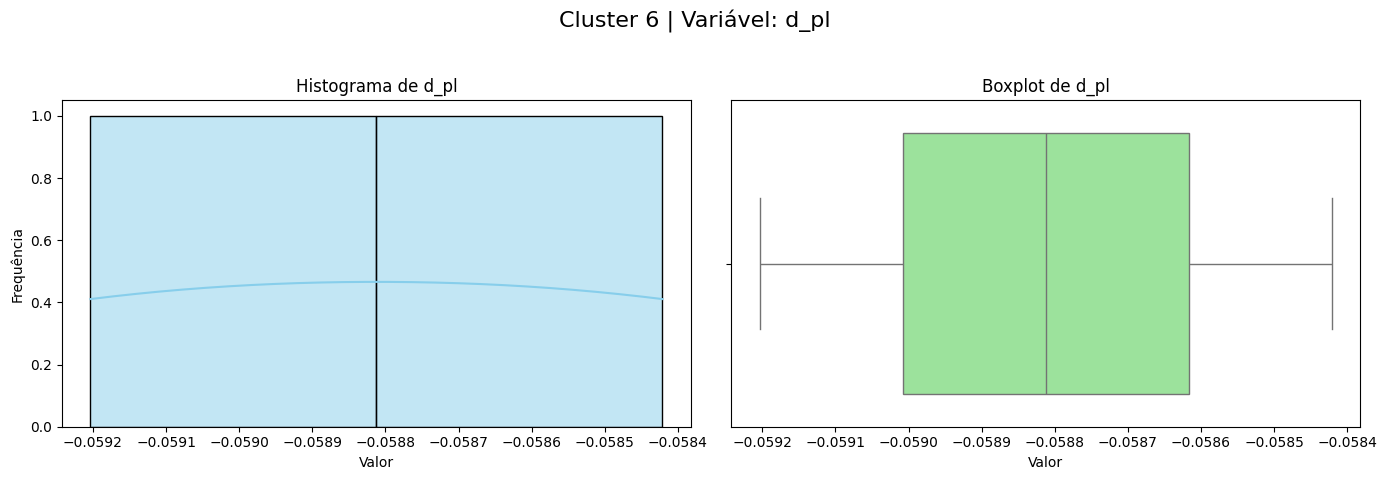

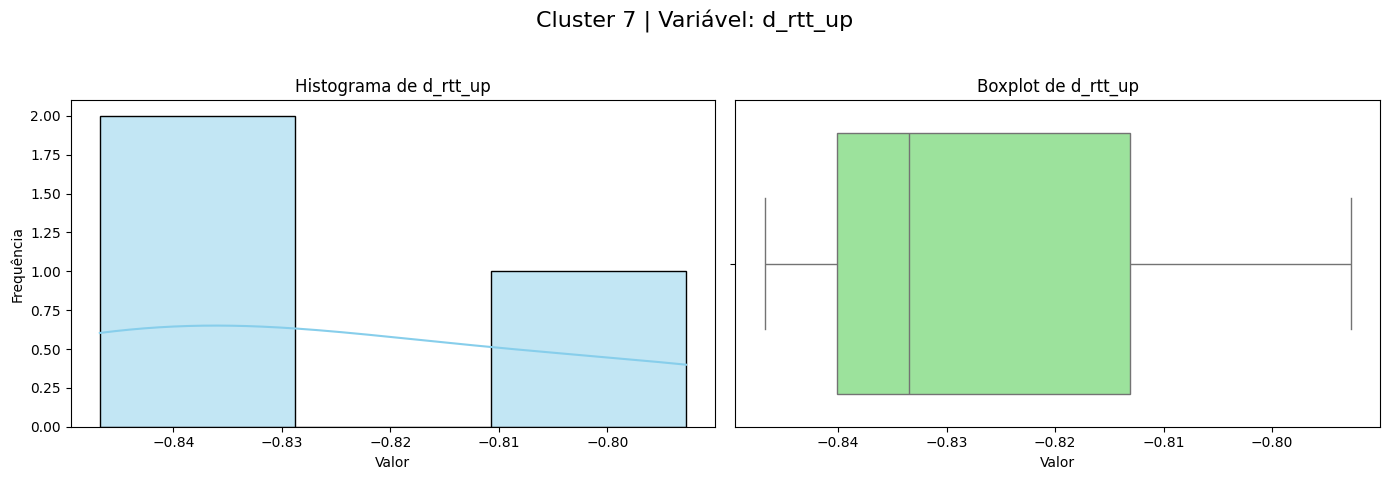

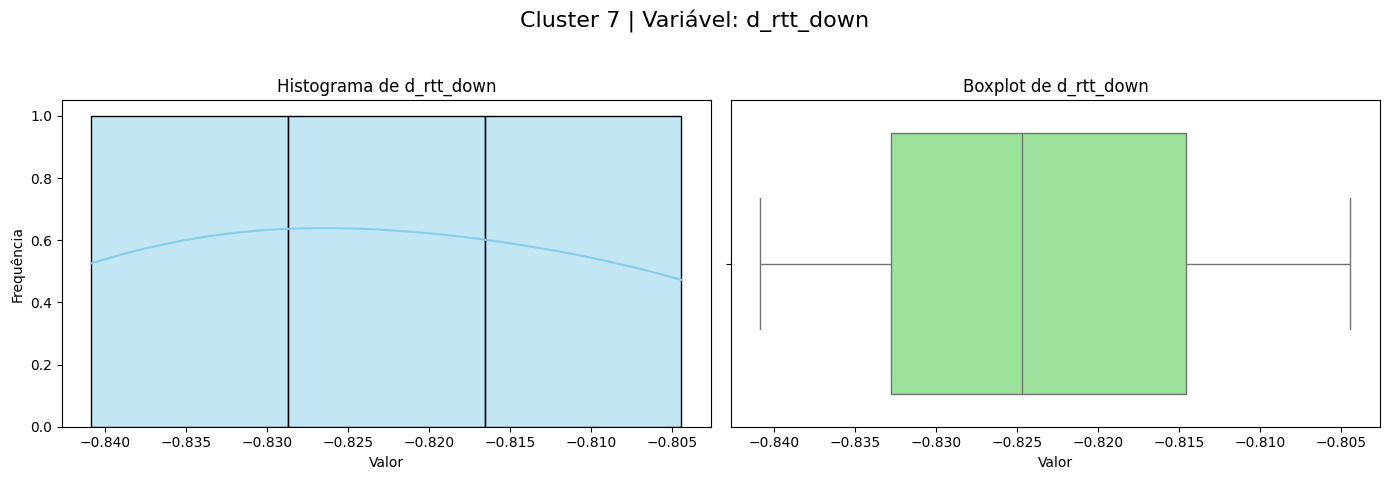

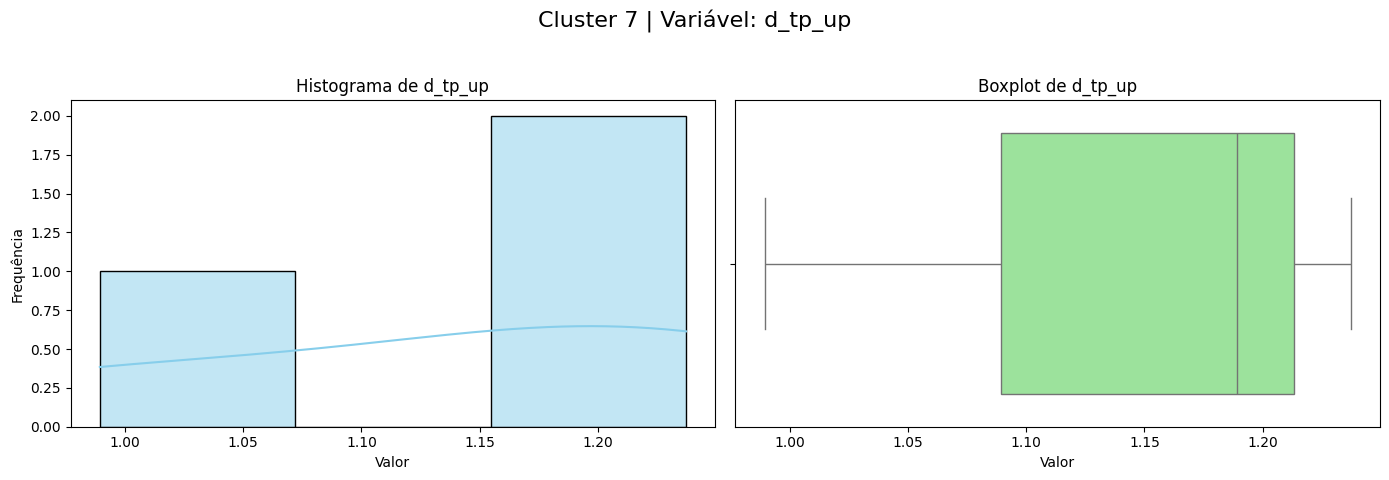

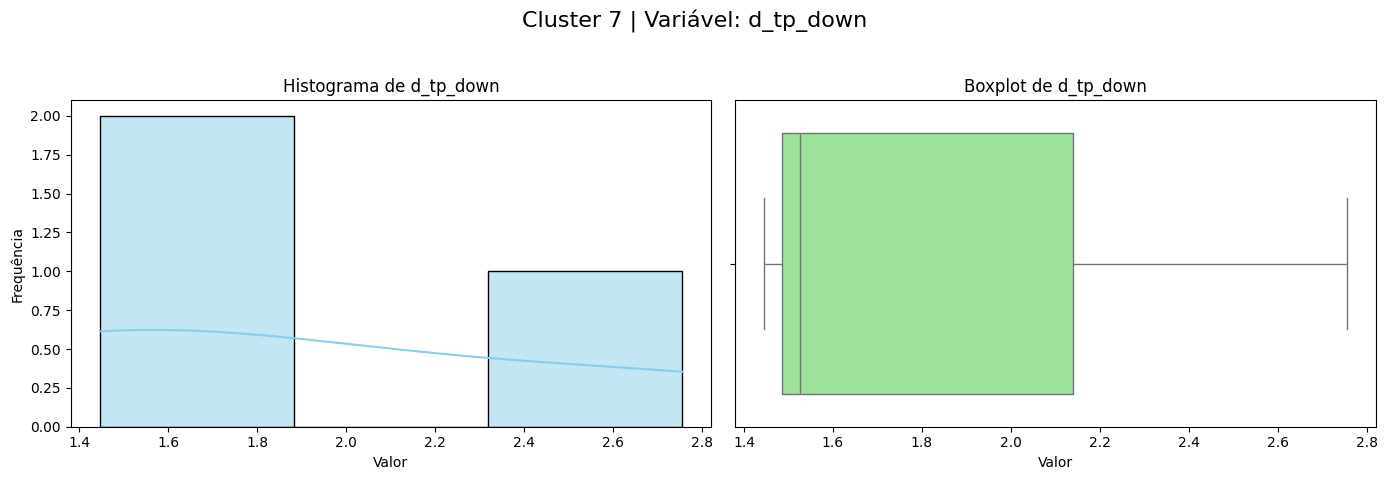

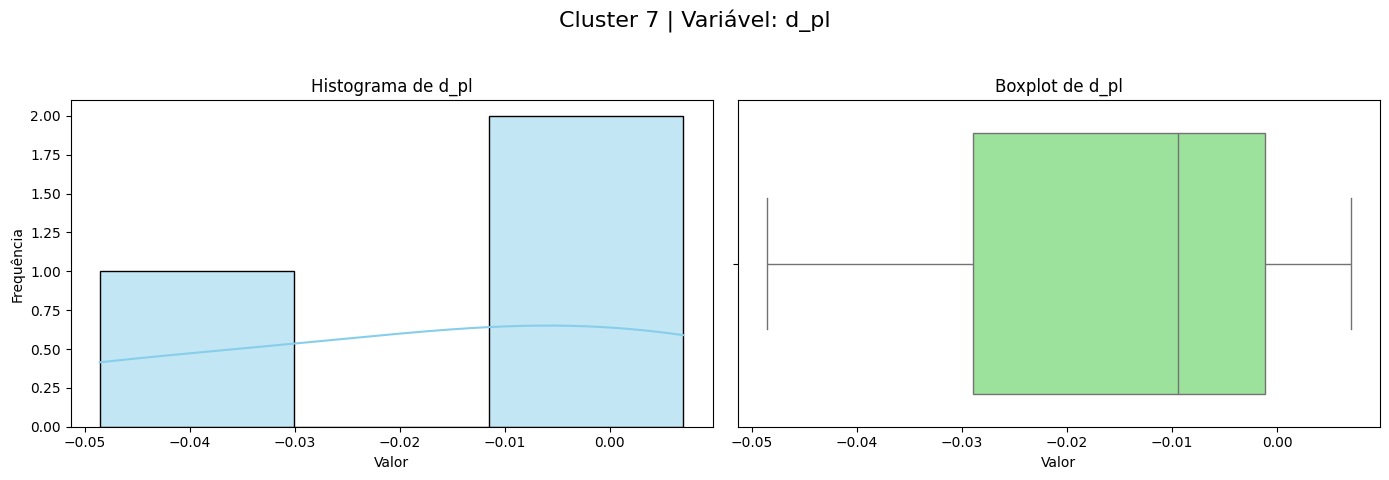

In [14]:
# Lista das variáveis de interesse
variables = ['d_rtt_up', 'd_rtt_down', 'd_tp_up', 'd_tp_down', 'd_pl']

# Obtendo os clusters únicos presentes no DataFrame
clusters = df_clusters['cluster'].unique()

# Ordenar os clusters para garantir uma apresentação consistente
clusters.sort()

for cluster in clusters:
    # Filtrando os dados para o cluster atual
    df_temp = df_clusters[df_clusters['cluster'] == cluster]
    
    for var in variables:
        # Criando uma nova figura com dois subplots (1 linha, 2 colunas)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Cluster {cluster} | Variável: {var}', fontsize=16)
        
        # Histograma com KDE (estimativa de densidade kernel)
        sns.histplot(df_temp[var], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Histograma de {var}')
        axes[0].set_xlabel('Valor')
        axes[0].set_ylabel('Frequência')
        
        # Boxplot
        sns.boxplot(x=df_temp[var], ax=axes[1], color='lightgreen')
        axes[1].set_title(f'Boxplot de {var}')
        axes[1].set_xlabel('Valor')
        
        # Ajusta o layout para evitar sobreposição
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()